## 0. Constants/Imports

In [10]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
WIENER_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
sys.path.insert(0,WIENER_DIR)
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

#My imports
from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.interaction import CAFInteraction
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from naming import *

#Weiner imports
from wienersvd import *
from unfolding_inputs import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [294]:
from datetime import date
day = date.today().strftime("%Y_%m_%d")

BASE_DIR = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora'
PLOT_DIR = f'{BASE_DIR}/plots/{day}'

MC_FNAME = f'{BASE_DIR}/mc_syst/v4/mc_smallpand_fullsyst_cut_norecomb.df'
MC_LOWE_FNAME = f'{BASE_DIR}/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df'
OFFBEAM_FNAME = f'{BASE_DIR}/offbeam/v4/mc_smallpand_nosyst_nocuts_recomb.df'
DATA_FNAME = f'{BASE_DIR}/data/v4/dataonbeam_nocuts.df'

FLUX_FILE = '/exp/sbnd/data/users/munjung/flux/sbnd_original_flux.root'

In [295]:
day

'2026_01_06'

In [13]:
NUMBER_TARGETS_FV

5.079980638121578e+31

## 1. Load data

In [14]:
# Get keys for h5 files
import h5py
mcnu_keys = []
mcnu_lowe_keys = []

#Slices - signal
mc_signal_pand_keys = []
mc_signal_lowe_pand_keys = []

#Slices - selected
mc_selected_pand_keys = []
mc_selected_lowe_pand_keys = []

#Slices
offbeam_pand_keys = []
data_pand_keys = []
#Tracks
mc_trk_keys = []
mc_lowe_trk_keys = []
offbeam_trk_keys = []
data_trk_keys = []


#Headers
hdr_keys = []
mc_lowe_hdr_keys = []
offbeam_hdr_keys = []
data_hdr_keys = []

#POT and total event keys
mc_pot_keys = []
mc_lowe_pot_keys = []
offbeam_pot_keys = []
data_pot_keys = []

mc_genevt_keys = []
mc_lowe_genevt_keys = []
offbeam_genevt_keys = []
data_genevt_keys = []
# Check the keys in the H5 Files
for fname in [MC_FNAME,OFFBEAM_FNAME,DATA_FNAME,MC_LOWE_FNAME]:
  print(f'File: {fname}')
  with h5py.File(f'{fname}', 'r') as f:
    # Store all keys at the root level
    for key in f.keys():
      if 'pand' in key:
        if fname == MC_FNAME:
          if 'signal' in key:
            mc_signal_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_pand_keys.append(key)
          else:
            mc_pand_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pand_keys.append(key)
        elif fname == DATA_FNAME:
          data_pand_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          if 'signal' in key:
            mc_signal_lowe_pand_keys.append(key)
          elif 'selected' in key:
            mc_selected_lowe_pand_keys.append(key)
          else:
            mc_lowe_pand_keys.append(key)
      elif 'trk' in key:
        if fname == MC_FNAME:
          mc_trk_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_trk_keys.append(key)
        elif fname == DATA_FNAME:
          data_trk_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_trk_keys.append(key)
      elif 'mcnu' in key:
        if fname == MC_FNAME:
          mcnu_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mcnu_lowe_keys.append(key)
      elif 'hdr' in key:
        if fname == MC_FNAME:
          hdr_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_hdr_keys.append(key)
        elif fname == DATA_FNAME:
          data_hdr_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_hdr_keys.append(key)
      elif 'histpotdf' in key:
        if fname == MC_FNAME:
          mc_pot_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_pot_keys.append(key)
        elif fname == DATA_FNAME:
          data_pot_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_pot_keys.append(key)
      elif 'histgenevtdf' in key:
        if fname == MC_FNAME:
          mc_genevt_keys.append(key)
        elif fname == OFFBEAM_FNAME:
          offbeam_genevt_keys.append(key)
        elif fname == DATA_FNAME:
          data_genevt_keys.append(key)
        elif fname == MC_LOWE_FNAME:
          mc_lowe_genevt_keys.append(key)

File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v4/mc_smallpand_fullsyst_cut_norecomb.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/offbeam/v4/mc_smallpand_nosyst_nocuts_recomb.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/v4/dataonbeam_nocuts.df
File: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_lowe/v4/mc_smallpand_fullsyst_cut_norecomb2.df


In [15]:
data_pand_keys

['evt_pand_0', 'evt_pand_1']

In [16]:
#Get POT from the h5
POT_MC = 0
for key in mc_pot_keys:
  potdf_mc = pd.read_hdf(MC_FNAME,key=key)
  POT_MC += potdf_mc.TotalPOT.values.sum()
print(f'POT_MC: {POT_MC:.2e}')

POT_MC_LOWE = 0
# for key in mc_lowe_pot_keys:
#   potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
#   POT_MC_LOWE += potdf_mc_lowe.TotalPOT.values.sum()
for key in mc_lowe_hdr_keys:
  potdf_mc_lowe = pd.read_hdf(MC_LOWE_FNAME,key=key)
  POT_MC_LOWE += potdf_mc_lowe.pot.values.sum()
print(f'POT_MC_LOWE: {POT_MC_LOWE:.2e}')

LIVETIME_OFFBEAM = 0
for key in offbeam_genevt_keys:
  genevt_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
  LIVETIME_OFFBEAM += genevt_offbeam.TotalGenEvents.values.sum()
# for key in offbeam_hdr_keys:
#   hdr_offbeam = pd.read_hdf(OFFBEAM_FNAME,key=key)
#   LIVETIME_OFFBEAM += hdr_offbeam.ngenevt.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')

LIVETIME_DATA = 0
POT_DATA = 0
for key in data_hdr_keys:
  hdr_data = pd.read_hdf(DATA_FNAME,key=key)
  LIVETIME_DATA += hdr_data.noffbeambnb.values.sum()
  POT_DATA += hdr_data.pot.values.sum()
LIVETIME_DATA = 9.51e5 # Temporary
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
print(f'POT_DATA: {POT_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
#print('WARNING: Setting LIVETIME_OFFBEAM to LIVETIME_DATA for now')
#LIVETIME_OFFBEAM = LIVETIME_DATA

POT_MC: 1.50e+18
POT_MC_LOWE: 6.01e+18
LIVETIME_OFFBEAM: 9.85e+04
LIVETIME_DATA: 9.51e+05
POT_DATA: 5.95e+18


In [17]:
mc_selected_lowe_pand_keys

['evt_pand_selected_0',
 'evt_pand_selected_1',
 'evt_pand_selected_2',
 'evt_pand_selected_3']

In [18]:
# while True:
#     response = input("Check the data being loaded in, I fuxked with what's being loded. Type 'yes' to accept and continue: ").strip().lower()
#     if response == 'yes':
#         break
#     print("Invalid input. Please type 'yes' to continue.")

#Selected
slc_mc_sel = CAFSlice.load(MC_FNAME,key=mc_selected_pand_keys,filter_univ=False)
slc_lowe_sel = CAFSlice.load(MC_LOWE_FNAME,key=mc_selected_lowe_pand_keys,filter_univ=False)
slc_offbeam_sel = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,filter_univ=False)
slc_offbeam_sel.cut_all(cut=True) #Apply cut to off beam since it's not applied (fix this later)

#Signal
slc_mc_signal = CAFSlice.load(MC_FNAME,key=mc_signal_pand_keys,filter_univ=False)
slc_lowe_signal = CAFSlice.load(MC_LOWE_FNAME,key=mc_signal_lowe_pand_keys,filter_univ=False)
slc_offbeam_signal = CAFSlice.load(OFFBEAM_FNAME,key=offbeam_pand_keys,filter_univ=False)

#Data
slc_data = CAFSlice.load(DATA_FNAME,key=data_pand_keys)

### 1.1 Rescale to MC POT (optional)

In [19]:
# POT_MC
# POT_LABEL = '3.48 x 10$^{20}$ POT'

In [20]:
# POT_DATA = 4.58e18
# old_pot_data = POT_DATA
# POT_DATA = 3.48e20 # Run 1 stats
# POT_LABEL = '3.48 x 10$^{20}$ POT'

# Rescale to POT_DATA
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_lowe_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam_sel.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

slc_mc_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC)
slc_lowe_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC_LOWE)
slc_offbeam_signal.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM)

--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to livetime (9.65e+00): 9.85e+04 --> 9.51e+05
--scaling to POT (3.97e+00): 1.50e+18 -> 5.95e+18
--scaling to POT (9.89e-01): 6.01e+18 -> 5.95e+18
--scaling to livetime (9.65e+00): 9.85e+04 --> 9.51e+05


In [21]:
#Combine
slc_mc_sel.combine(slc_lowe_sel,duplicate_ok=True)
del slc_lowe_sel
slc_mc_sel.combine(slc_offbeam_sel,duplicate_ok=True,offset=int(2e5))
del slc_offbeam_sel

slc_mc_signal.combine(slc_lowe_signal,duplicate_ok=True)
del slc_lowe_signal
slc_mc_signal.combine(slc_offbeam_signal,duplicate_ok=True,offset=int(2e5))
del slc_offbeam_signal

### 1.2 Assign binnings

In [22]:
# Binning 2d class
from sbnd.cafclasses.binning import Binning2D
binning2d = Binning2D()
# #Used for 2D binning
# DIFF_COSTHETA_BINS = np.array([-1,-0.5,0,0.27,0.45,0.62,0.76,0.86,0.94,1])
# DIFF_COSTHETA_BIN_LABELS = [f'{DIFF_COSTHETA_BINS[i]:.2f} - {DIFF_COSTHETA_BINS[i+1]:.2f}' for i in range(len(DIFF_COSTHETA_BINS)-1)]
# DIFF_COSTHETA_CENTERS = (DIFF_COSTHETA_BINS[:-1] + DIFF_COSTHETA_BINS[1:])/2.

# DIFF_THETA_BINS = np.arccos(DIFF_COSTHETA_BINS)*180/np.pi
# DIFF_THETA_BIN_LABELS = [f'{DIFF_THETA_BINS[i]:.2f} - {DIFF_THETA_BINS[i+1]:.2f}' for i in range(len(DIFF_THETA_BINS)-1)]
# DIFF_THETA_CENTERS = (DIFF_THETA_BINS[:-1] + DIFF_THETA_BINS[1:])/2.

# DIFF_MOMENTUM_BINS = np.array([0,0.3,0.5,0.7,1.1,1e10])
# DIFF_MOMENTUM_BIN_LABELS = [f'{DIFF_MOMENTUM_BINS[i]:.2f} - {DIFF_MOMENTUM_BINS[i+1]:.2f}' if i < len(DIFF_MOMENTUM_BINS)-2 else f'> {DIFF_MOMENTUM_BINS[i]:.2f}' for i in range(len(DIFF_MOMENTUM_BINS)-1)]
# DIFF_MOMENTUM_CENTERS = (DIFF_MOMENTUM_BINS[:-1] + DIFF_MOMENTUM_BINS[1:])/2.

# DIFFERENTIAL_BINS = (len(DIFF_COSTHETA_BINS)-2) + (len(DIFF_MOMENTUM_BINS)-2)*(len(DIFF_COSTHETA_BINS)-1)
# DIFFERENTIAL_EDGES = np.arange(-1.5,np.max(DIFFERENTIAL_BINS)+1.5,1)
# DIFFERENTIAL_CENTERS = (DIFFERENTIAL_EDGES[:-1] + DIFFERENTIAL_EDGES[1:])/2.

# diff_dict_template = {
#   #Differential bin id is the key
#   'costheta_bin': -1,
#   'momentum_bin': -1,
#   'costheta_edges': [-np.inf,np.inf],
#   'momentum_edges': [-np.inf,np.inf],
#   'momentum_center': -np.inf,
#   'costheta_center': -np.inf
# }
# DIFFERENTIAL_CENTERS
# DIFFERENTIAL_DICTS = {c:diff_dict_template.copy() for c in sorted(DIFFERENTIAL_CENTERS[1:])}
# for c in DIFFERENTIAL_DICTS:
#   #differential_bins = slc.data.true_bin.costheta.values.astype(float) + slc.data.true_bin.momentum.values.astype(float)*np.max(slc.data.true_bin.costheta.values.astype(float))
  
#   c = int(c)
#   cbin = np.mod(c,len(diff_costheta_bins)-1)
#   pbin = c//(len(costheta_bins)-1)
#   DIFFERENTIAL_DICTS[c]['costheta_bin'] = cbin
#   DIFFERENTIAL_DICTS[c]['momentum_bin'] = pbin
#   DIFFERENTIAL_DICTS[c]['costheta_edges'] = DIFF_COSTHETA_BINS[cbin:cbin+2]
#   DIFFERENTIAL_DICTS[c]['momentum_edges'] = DIFF_MOMENTUM_BINS[pbin:pbin+2]
#   DIFFERENTIAL_DICTS[c]['momentum_center'] = DIFF_MOMENTUM_CENTERS[pbin]
#   DIFFERENTIAL_DICTS[c]['costheta_center'] = DIFF_COSTHETA_CENTERS[cbin]

In [23]:
costheta_bins = COSTHETA_BINS
momentum_bins = MOMENTUM_BINS

diff_momentum_bins = DIFF_MOMENTUM_BINS
diff_costheta_bins = DIFF_COSTHETA_BINS

costheta_bin_widths = np.diff(costheta_bins)
momentum_bin_widths = np.diff(momentum_bins)

diff_momentum_bin_widths = np.diff(diff_momentum_bins)
diff_costheta_bin_widths = np.diff(diff_costheta_bins)

costheta_centers = (costheta_bins[:-1] + costheta_bins[1:])/2.
momentum_centers = (momentum_bins[:-1] + momentum_bins[1:])/2.
momentum_centers[-1] = 3.5 #Because the last bin is enormous

diff_momentum_centers = (binning2d.diff_momentum_bins[:-1] + binning2d.diff_momentum_bins[1:])/2.
diff_costheta_centers = (binning2d.diff_costheta_bins[:-1] + binning2d.diff_costheta_bins[1:])/2.
diff_momentum_centers[-1] = 3.5 #Because the last bin is enormous

differential_bins = binning2d.differential_bins
differential_centers = binning2d.differential_centers
differential_edges = binning2d.differential_edges
differential_dicts = binning2d.differential_dicts

#Assign binnings based on momentum and costheta
for i,slc in enumerate([slc_data,slc_mc_sel,slc_mc_signal]):
#for i,slc in enumerate([slc_mc_sel]):
  print(i)
  #TEMPORARY - Cut if has_muon is Nan (due to bug in cafclasses that I fixed)
  slc.data = slc.data[slc.data.has_muon == True]
  #TEMPORARY - Add totp for true particle matched to muon
  totp = np.sqrt(slc.data.mu.pfp.trk.truth.p.genp.x**2 + slc.data.mu.pfp.trk.truth.p.genp.y**2 + slc.data.mu.pfp.trk.truth.p.genp.z**2)
  slc.add_cols('mu.pfp.trk.truth.p.totp',totp)
  dirz = slc.data.mu.pfp.trk.truth.p.genp.z/totp
  slc.add_cols('mu.pfp.trk.truth.p.dir.z',dirz)
  #TEMPORARY - add stat binning
  if i != 0:
    slc.add_stat_unc()
  #Truth binnings
  slc.assign_bins(diff_costheta_bins,'truth.mu.dir.z',assign_key='true_bin.costheta')
  slc.assign_bins(diff_momentum_bins,'truth.mu.totp',assign_key='true_bin.momentum')
  #If there is no true muon, set the binning based on the true matched particle
  m1 = slc.data.true_bin.costheta == -1
  if np.sum(m1) > 0:
    print(np.sum(m1)/len(m1))
    slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.truth.p.dir.z',assign_key='true_bin.costheta',mask=m1)
    slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.truth.p.totp',assign_key='true_bin.momentum',mask=m1)

  mask = slc.data.true_bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  print(f'Missing true bin: {mask}')
  differential_bins = slc.data.true_bin.costheta.values.astype(float) + slc.data.true_bin.momentum.values.astype(float)*np.max(slc.data.true_bin.costheta.values.astype(float))
  slc.add_cols('true_bin.differential',differential_bins[mask],conditions=mask,fill=-1.)
  
  #Reco binnings
  slc.assign_bins(diff_costheta_bins,'mu.pfp.trk.costheta',assign_key='bin.costheta')
  slc.assign_bins(diff_momentum_bins,'mu.pfp.trk.P.p_muon',assign_key='bin.momentum')

  mask = slc.data.bin.values.astype(float) >= 0
  mask = np.all(mask,axis=1)
  differential_bins = slc.data.bin.costheta.values.astype(float) + slc.data.bin.momentum.values.astype(float)*np.max(slc.data.bin.costheta.values.astype(float))
  slc.add_cols('bin.differential',differential_bins[mask],conditions=mask,fill=-1.)



0
1.0
Missing true bin: [False False False ... False False False]
1


Generating event seeds: 100%|██████████| 4047/4047 [00:00<00:00, 110289.64it/s]


Successfully generated 4047 unique seeds


Generating universes: 100%|██████████| 100/100 [00:01<00:00, 75.61it/s]


0.04398319743019521
Missing true bin: [ True  True  True ...  True  True  True]
2


Generating event seeds: 100%|██████████| 6239/6239 [00:00<00:00, 112428.84it/s]


Successfully generated 6239 unique seeds


Generating universes: 100%|██████████| 100/100 [00:02<00:00, 48.64it/s]


Missing true bin: [ True  True  True ...  True  True  True]


In [24]:
#This should be empty
m1 = slc_mc_sel.data.true_bin.differential == -1
assert len(slc_mc_sel.data[m1]) == 0, f'{len(slc_mc_sel.data[m1])} slices have no differential bin'

In [25]:
slc_mc_sel.data.true_bin.differential.value_counts()

differential
40.0    383
31.0    282
30.0    251
32.0    218
21.0    197
12.0    186
39.0    183
13.0    180
22.0    176
29.0    165
23.0    149
11.0    149
9.0     130
10.0    128
14.0    127
20.0    125
0.0     115
1.0     103
24.0     89
15.0     84
16.0     69
19.0     67
3.0      56
38.0     55
5.0      53
8.0      53
2.0      53
28.0     44
4.0      40
6.0      39
18.0     31
7.0      22
37.0     15
17.0     10
27.0      9
26.0      4
33.0      4
36.0      1
25.0      1
34.0      1
Name: count, dtype: int64

In [26]:
# plt.hist(slc_mc_sel.data.mu.pfp.trk.P.p_muon,bins=[0,0.3,0.5,0.7,1.1,5.])
# plt.xlim(0,3)

### 1.2 Extract selected signal

In [27]:
is_signal = np.isin(slc_mc_sel.data.truth.event_type,[0,1])
slc_mc_sel_signal = CAFSlice(slc_mc_sel.data[is_signal])
slc_mc_sel_background = CAFSlice(slc_mc_sel.data[~is_signal])

In [28]:
m1 = slc_mc_sel_background.data.bin.costheta == -1
slc_mc_sel_background.data[m1].has_muon

Series([], Name: has_muon, dtype: object)

### 1.3 Flux

In [29]:
# Extract flux from the flux file
flux = uproot.open(FLUX_FILE)

# numu flux
numu_flux = flux["flux_sbnd_numu"].to_numpy()
bin_edges = numu_flux[1]
flux_vals = numu_flux[0]

# get integrated flux
integrated_flux = flux_vals.sum()
integrated_flux /= 1e4 # to cm2
INTEGRATED_FLUX = np.float64(integrated_flux * POT_DATA / 1e6) # POT
print("Integrated flux: %.3e" % INTEGRATED_FLUX)

Integrated flux: 9.608e+10


In [30]:
integrated_flux*1e2

1.6148681640625

In [31]:
#XSEC_UNIT = 1/ (INTEGRATED_FLUX * NTARGETS)
XSEC_UNIT = 1/ (INTEGRATED_FLUX * NUMBER_TARGETS_FV)
print(f'Xsec unit: {XSEC_UNIT}')

Xsec unit: 2.0488476918781626e-43


### 1.4 Get binnings

In [32]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/slc_weights.txt','w') as f:
  for key in slc_mc_sel.data.truth.keys():
    f.write(f'{key}\n')

In [33]:
#Selected
genweights = slc_mc_sel.data.genweight.values

reco_costheta = slc_mc_sel.data.mu.pfp.trk.costheta
reco_costheta_bin = slc_mc_sel.data.bin.costheta
true_costheta = slc_mc_sel.data.truth.mu.dir.z
true_costheta_bin = slc_mc_sel.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_costheta == -1
true_costheta[m1] = slc_mc_sel.data.mu.pfp.trk.truth.p.dir.z[m1]
data_costheta = slc_data.data.mu.pfp.trk.costheta
data_costheta_bin = slc_data.data.bin.costheta

reco_momentum = slc_mc_sel.data.mu.pfp.trk.P.p_muon
reco_momentum_bin = slc_mc_sel.data.bin.momentum
true_momentum = slc_mc_sel.data.truth.mu.totp
true_momentum_bin = slc_mc_sel.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_momentum == -1
true_momentum[m1] = slc_mc_sel.data.mu.pfp.trk.truth.p.totp[m1]

data_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_momentum_bin = slc_data.data.bin.momentum

reco_differential = slc_mc_sel.data.bin.differential
true_differential = slc_mc_sel.data.true_bin.differential
data_differential = slc_data.data.bin.differential

#Selected signal
genweights_sel = slc_mc_sel_signal.data.genweight.values

reco_sel_costheta = slc_mc_sel_signal.data.mu.pfp.trk.costheta
reco_sel_costheta_bin = slc_mc_sel_signal.data.bin.costheta
true_sel_costheta = slc_mc_sel_signal.data.truth.mu.dir.z
true_sel_costheta_bin = slc_mc_sel_signal.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_sel_costheta == -1
true_sel_costheta[m1] = slc_mc_sel_signal.data.mu.pfp.trk.truth.p.dir.z[m1]

data_sel_costheta = slc_data.data.mu.pfp.trk.costheta
data_sel_costheta_bin = slc_data.data.bin.costheta

reco_sel_momentum = slc_mc_sel_signal.data.mu.pfp.trk.P.p_muon
reco_sel_momentum_bin = slc_mc_sel_signal.data.bin.momentum
true_sel_momentum = slc_mc_sel_signal.data.truth.mu.totp
true_sel_momentum_bin = slc_mc_sel_signal.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_sel_momentum == -1
true_sel_momentum[m1] = slc_mc_sel_signal.data.mu.pfp.trk.truth.p.totp[m1]
data_sel_momentum = slc_data.data.mu.pfp.trk.P.p_muon
data_sel_momentum_bin = slc_data.data.bin.momentum

reco_sel_differential = slc_mc_sel_signal.data.bin.differential
true_sel_differential = slc_mc_sel_signal.data.true_bin.differential

#Selected background
genweights_sel_background = slc_mc_sel_background.data.genweight.values

reco_sel_background_costheta = slc_mc_sel_background.data.mu.pfp.trk.costheta
reco_sel_background_costheta_bin = slc_mc_sel_background.data.bin.costheta
true_sel_background_costheta = slc_mc_sel_background.data.truth.mu.dir.z
true_sel_background_costheta_bin = slc_mc_sel_background.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon
m1 = true_sel_background_costheta == -1
true_sel_background_costheta[m1] = slc_mc_sel_background.data.mu.pfp.trk.truth.p.dir.z[m1]

reco_sel_background_momentum = slc_mc_sel_background.data.mu.pfp.trk.P.p_muon
reco_sel_background_momentum_bin = slc_mc_sel_background.data.bin.momentum
true_sel_background_momentum = slc_mc_sel_background.data.truth.mu.totp
true_sel_background_momentum_bin = slc_mc_sel_background.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon
m1 = true_sel_background_momentum == -1
true_sel_background_momentum[m1] = slc_mc_sel_background.data.mu.pfp.trk.truth.p.totp[m1]

reco_sel_background_differential = slc_mc_sel_background.data.bin.differential
true_sel_background_differential = slc_mc_sel_background.data.true_bin.differential


#Signal
mask = slc_mc_signal.data.index.isin(slc_mc_signal.data.slc.tmatch.eff.groupby(level=[0,1]).idxmax().dropna())
slc_mc_signal.data = slc_mc_signal.data[mask] #mask out anything that isn't the best match

genweights_sig = slc_mc_signal.data.genweight.values
#SLC
reco_sig_costheta = slc_mc_signal.data.mu.pfp.trk.costheta
reco_sig_costheta_bin = slc_mc_signal.data.bin.costheta
true_sig_costheta = slc_mc_signal.data.truth.mu.dir.z
true_sig_costheta_bin = slc_mc_signal.data.true_bin.costheta
#Fix the costheta for selected slices that don't have a true muon (this should'nt happen for signal)
m1 = true_sig_costheta == -1
if np.sum(m1) > 0: print(f'Warning: {np.sum(m1)} signal slices have no true muon')
true_sig_costheta[m1] = slc_mc_signal.data.mu.pfp.trk.truth.p.dir.z[m1]

reco_sig_momentum = slc_mc_signal.data.mu.pfp.trk.P.p_muon
reco_sig_momentum_bin = slc_mc_signal.data.bin.momentum
true_sig_momentum = slc_mc_signal.data.truth.mu.totp
true_sig_momentum_bin = slc_mc_signal.data.true_bin.momentum
#Fix the momentum for selected slices that don't have a true muon (this should'nt happen for signal)
m1 = true_sig_momentum == -1
if np.sum(m1) > 0: print(f'Warning: {np.sum(m1)} signal slices have no true muon')
true_sig_momentum[m1] = slc_mc_signal.data.mu.pfp.trk.truth.p.totp[m1]

reco_sig_differential = slc_mc_signal.data.bin.differential
true_sig_differential = slc_mc_signal.data.true_bin.differential

#For plotting
label_y_shift = 0.

In [34]:
np.sum(genweights_sel)/np.sum(genweights_sig)

0.6134029023316485

In [35]:
from sbnd.general.utils import get_sys_keydict

In [36]:
# allsysts = get_sys_keylist(slc_mc_signal.data.truth.keys())
# allweights = [None]*len(allsysts)
# for i,s in tqdm(enumerate(allsysts),total=len(allsysts),unit=' goomba'):
#   allkeys = get_sys_keys(s,slc_mc_signal.data.truth.keys())
#   allweights[i] = get_weights_from_sys_keys(allkeys,slc_mc_signal.data[mask])
# allweights[0].shape

In [37]:
# def plot_cv_weights(vals,weights,genweights,bins,label='',xlabel='',ylabel='Candidates',ignore_nan=True,**kwargs):
#   fig,ax = plt.subplots()
#   for i,_weights in enumerate(weights.T):
#     if ignore_nan:
#       _weights = np.where(np.isnan(_weights),0,_weights)
#     if i == 0:
#       ax.hist(vals,weights=_weights*genweights,bins=bins,label=label,histtype='step',color='blue',alpha=0.1,**kwargs)
#     else:
#       ax.hist(vals,weights=_weights*genweights,bins=bins,histtype='step',color='blue',alpha=0.1,**kwargs)
#   ax.hist(vals,weights=genweights,bins=bins,label='CV',histtype='step',color='black',**kwargs)
#   ax.set_xlabel(xlabel)
#   ax.set_ylabel(ylabel)
#   ax.legend()
#   return fig,ax

In [38]:
# for i,(w,s) in enumerate(zip(allweights,allsysts)):
#   fig,ax = plot_cv_weights(reco_sig_costheta,w,genweights_sig,costheta_bins,label=s,xlabel=r'Reconstructed $\cos\theta_{\mu}$')
#   plotters.save_plot(f'reco_costheta_cv_weights_{i}',fig=fig,folder_name=f'{PLOT_DIR}/syst/pandora')
#   ax.set_title(f'{s}')
#   break
  #fig.savefig(f'{PLOT_DIR}/flux/pandora/cv_weights_{i}.png')
  #plt.close(fig)


## 3. Response matrix

### 3.1 Efficiency and signal vs selected

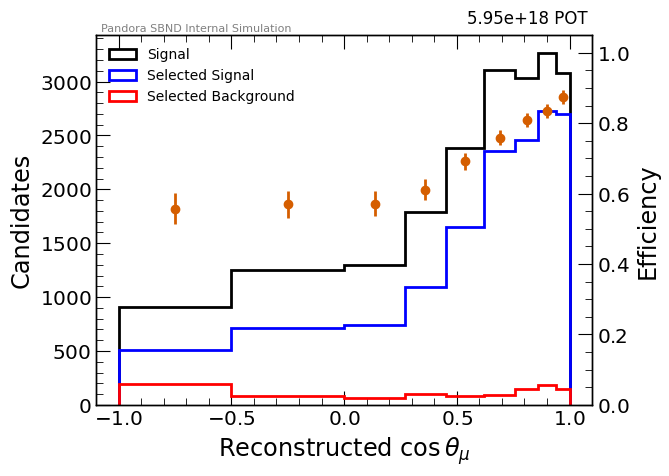

In [75]:
fig,ax = plt.subplots()
slc_costheta_sig,_,_ = ax.hist(reco_sig_costheta,bins=costheta_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_costheta_sel,_,_ = ax.hist(reco_sel_costheta,bins=costheta_bins,weights=genweights_sel,label='Selected Signal',histtype='step',color='blue',alpha=1.)
slc_costheta_sel_background,_,_ = ax.hist(reco_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_costheta_eff = slc_costheta_sel/slc_costheta_sig
assert np.nanmax(slc_costheta_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_costheta_eff)}'
ax2 = ax.twinx()
#ax2.scatter(costheta_centers,slc_costheta_eff,label='Efficiency')
ax2.errorbar(costheta_centers,slc_costheta_eff,yerr=1/np.sqrt(slc_costheta_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_costheta_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

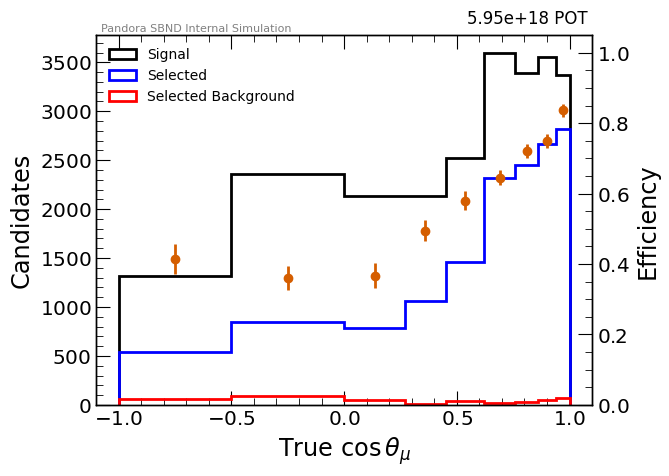

In [40]:
fig,ax = plt.subplots()
slc_costheta_sig_truth,_,_ = ax.hist(true_sig_costheta,bins=costheta_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_costheta_sel_truth,_,_ = ax.hist(true_sel_costheta,bins=costheta_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_costheta_sel_background_truth,_,_ = ax.hist(true_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_costheta_eff_truth = slc_costheta_sel_truth/slc_costheta_sig_truth
assert np.nanmax(slc_costheta_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_costheta_eff)}'
ax2 = ax.twinx()
#ax2.scatter(costheta_centers,slc_costheta_eff_truth,label='Efficiency')
ax2.errorbar(costheta_centers,slc_costheta_eff_truth,yerr=1/np.sqrt(slc_costheta_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_costheta_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

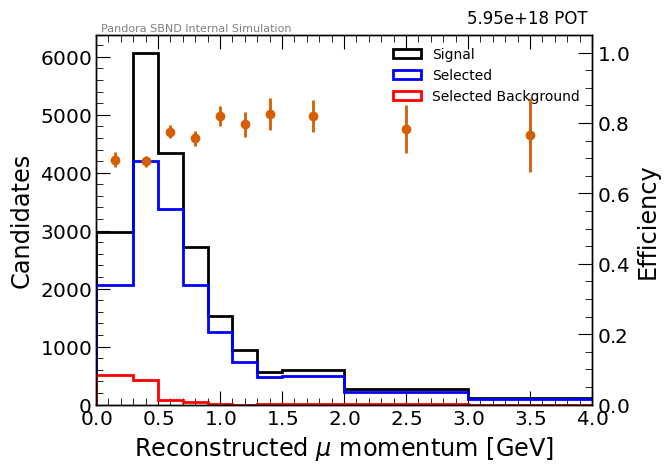

In [41]:
fig,ax = plt.subplots()
slc_momentum_sig,_,_ = ax.hist(reco_sig_momentum,bins=momentum_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_momentum_sel,_,_ = ax.hist(reco_sel_momentum,bins=momentum_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_momentum_sel_background,_,_ = ax.hist(reco_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_momentum_eff = slc_momentum_sel/slc_momentum_sig
assert np.nanmax(slc_momentum_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_momentum_eff)}'
ax2 = ax.twinx()
#ax2.scatter(momentum_centers,slc_momentum_eff,label='Efficiency')
ax2.errorbar(momentum_centers,slc_momentum_eff,yerr=1/np.sqrt(slc_momentum_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax.set_xlim(0,4.)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_momentum_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

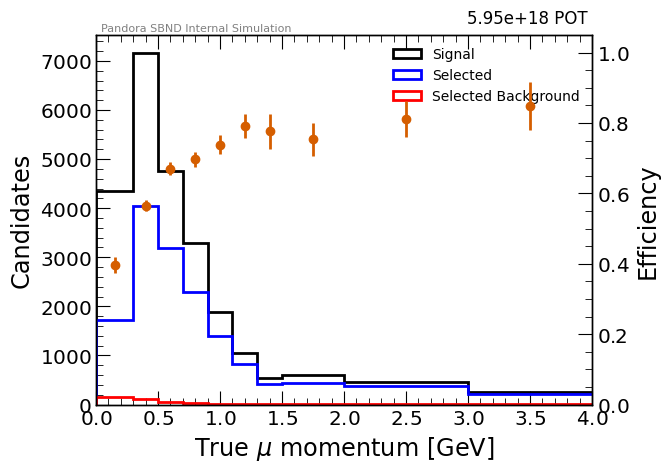

In [42]:
fig,ax = plt.subplots()
slc_momentum_sig_truth,_,_ = ax.hist(true_sig_momentum,bins=momentum_bins,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_momentum_sel_truth,_,_ = ax.hist(true_sel_momentum,bins=momentum_bins,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_momentum_sel_background_truth,_,_ = ax.hist(true_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_momentum_eff_truth = slc_momentum_sel_truth/slc_momentum_sig_truth
assert np.nanmax(slc_momentum_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_momentum_eff)}'
ax2 = ax.twinx()
#ax2.scatter(momentum_centers,slc_momentum_eff_truth,label='Efficiency')
ax2.errorbar(momentum_centers,slc_momentum_eff_truth,yerr=1/np.sqrt(slc_momentum_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax.set_xlim(0,4.)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_momentum_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

In [43]:
differential_dicts[34]

{'costheta_bin': 7,
 'momentum_bin': 3,
 'costheta_edges': array([0.86, 0.94]),
 'momentum_edges': array([0.7, 1.1]),
 'momentum_center': 0.9,
 'costheta_center': 0.8999999999999999}

In [44]:
def bin_differential_dict(series2,bins1,bins2,diff_dicts,weights=None,bin_by='costheta'):
  """
  Bin series2 into bins of bins1. Create histograms for each bin of series2.

  Parameters
  ----------
  series2 : array-like (N or B)
    The series to bin into the bins of series1.
  bins1: array-like (N or B)
    The bins that series2 is being binned into. Should map 1:1 with series2.
    If length is B, then we assume series2 is arranged by the differential bins.
  bins2 : array-like (B)
    The bins to bin series2 into.
  diff_dicts : list of dicts
    The differential dictionaries to use for the histograms. Contains the edges and labels for each differential bin.
  weights : array-like (N)
    The weights to use for the histograms.
  bin_by : str
    The series to bin by.

  Returns
  -------
  dictionary of histograms for each bin of series1. Each histogram is a tuple of (counts,bin_edges).
  The keys are the unique values of bin_by.
  """
  assert len(series2) == len(bins1) == len(weights), f'Series2 and bins1 and weights must be the same length: {len(series2)} != {len(bins1)} != {len(weights)}'
  #Initialize the histogram dictionary by the unique values of bin_by key
  keys = np.unique([v[f'{bin_by}_bin'] for v in diff_dicts.values()])
  hist_dict = {k:None for k in keys}

  #Get bin edges for the bin_by series
  bin_by_edges = np.unique([np.array(v[f'{bin_by}_edges']) for v in diff_dicts.values()],axis=0)

  #Loop over the unique values of bin_by
  for k in keys:
    mask = bins1 == k
    hist_dict[k] = np.histogram(series2[mask],bins=bins2,weights=weights[mask])

  assert len(bin_by_edges) == len(hist_dict), f'bin_by_edges and hist_dict must be the same length: {len(bin_by_edges)} != {len(hist_dict)}'
  return hist_dict,bin_by_edges

In [45]:
bin_differential_dict(reco_sig_momentum,reco_sig_costheta_bin,diff_momentum_bins,genweights_sig,differential_dicts);

AssertionError: Series2 and bins1 and weights must be the same length: 6133 != 6133 != 45

In [46]:
def plot_differential_hist(series2,bins1,bins2,weights,diff_dicts,bin_by='costheta',
  xlabel='',ylabel='Candidates',label='',fig=None,axs=None,legend=False,add_labels=False,**kwargs):
  """
  Plot the differential histograms for each bin of bins1.

  Parameters
  ----------
  series2 : array-like (N or B)
    The series to bin into the bins of series1. If length is N, then series2 is binned into the bins of series1. 
    If length is B, then we assume series2 is arranged by the differential bins.
  bins1: array-like (N or B)
    The bins that series2 is being binned into. Should map 1:1 with series2.
    If length is B, then we assume 
  bins2 : array-like (B)
    The bins to bin series2 into.
  weights : array-like (N)
    The weights to use for the histograms.
  diff_dicts : list of dicts
    The differential dictionaries to use for the histograms. Contains the edges and labels for each differential bin.
  bin_by : str
    The series to bin by.
  label : str
    The label to use for the histograms.
  fig : matplotlib.figure.Figure
    The figure to use for the histograms.
  axs : matplotlib.axes.Axes
    The axes to use for the histograms.
  **kwargs : dict
    Keyword arguments to pass to the plotting function.

  Returns
  -------
  fig : matplotlib.figure.Figure
    The figure containing the differential histograms.
  axs : matplotlib.axes.Axes
    The axes containing the differential histograms.
  """
  bin_by_text = r'$\cos\theta_{\mu}$' if bin_by == 'costheta' else r'$p_{\mu}$'
  #Get hist_dict
  hist_dict,bin_by_edges = bin_differential_dict(series2,bins1,bins2,weights,diff_dicts,bin_by=bin_by)
  #TODO: Adjust this to be dynamic based on costheta binning
  if fig is None and axs is None: fig,axs = plt.subplots(figsize=(12,8),nrows=3,ncols=3)
  assert len(axs.flatten()) == len(hist_dict), f'axs and hist_dict must be the same length: {len(axs.flatten())} != {len(hist_dict)}'
  for ax,h,b in zip(axs.flatten(),hist_dict.values(),bin_by_edges):
    makeplot.plot_hist_edges(h[1],h[0],None,label,ax=ax,**kwargs)
    if bin_by == 'costheta': ax.set_xlim(0,4.)
    bin_text = f'{b[0]:.2f} < {bin_by_text} < {b[1]:.2f}'
    if add_labels: plotters.add_label(ax,bin_text,where='centerright',color='black',alpha=1.,fontsize=8)
  #Add the labels
  axs[2,1].set_xlabel(xlabel)
  axs[1,0].set_ylabel(ylabel)
  if legend: axs[0,2].legend(bbox_to_anchor=(1.05,1),loc='upper left')
  return fig,axs
def plot_differential_scatter(series2,bins1,bins2,weights,diff_dicts,bin_by='costheta',
  xlabel='',ylabel='Candidates',label='',fig=None,axs=None,add_labels=False,legend=False,**kwargs):
  """
  Plot the differential scatter plot for each bin of bins1.
  
  Parameters
  ----------
  series2 : array-like (N)
    The series to bin into the bins of series1.
  bins1: array-like (N)
    The bins that series2 is being binned into. Should map 1:1 with series2.
  bins2 : array-like (B)
    The bins to bin series2 into.
  weights : array-like (N)
    The weights to use for the scatter plot.
  diff_dicts : list of dicts
    The differential dictionaries to use for the scatter plot. Contains the edges and labels for each differential bin.
  bin_by : str
    The series to bin by.
  xlabel : str
    The label for the x-axis.
  ylabel : str
    The label for the y-axis.
  label : str
    The label for the scatter plot.
  fig : matplotlib.figure.Figure
    The figure to use for the scatter plot.
  axs : matplotlib.axes.Axes
    The axes to use for the scatter plot.
  add_labels : bool
    Whether to add the labels to the scatter plot.
  legend : bool
    Whether to add the legend to the scatter plot.
  **kwargs : dict
    Keyword arguments to pass to the plotting function.

  Returns
  -------
  fig : matplotlib.figure.Figure
    The figure containing the scatter plot.
  axs : matplotlib.axes.Axes
    The axes containing the scatter plot.
  """
  bin_by_text = r'$\cos\theta_{\mu}$' if bin_by == 'costheta' else r'$p_{\mu}$'
  #Get hist_dict
  hist_dict,bin_by_edges = bin_differential_dict(series2,bins1,bins2,weights,diff_dicts,bin_by=bin_by)
  #TODO: Adjust this to be dynamic based on costheta binning
  if fig is None and axs is None: fig,axs = plt.subplots(figsize=(12,8),nrows=3,ncols=3)
  assert len(axs.flatten()) == len(hist_dict), f'axs and hist_dict must be the same length: {len(axs.flatten())} != {len(hist_dict)}'
  for ax,h,b in zip(axs.flatten(),hist_dict.values(),bin_by_edges):
    makeplot.plot_hist_edges(h[1],h[0],None,label,ax=ax,**kwargs)
    if bin_by == 'costheta': ax.set_xlim(0,4.)
    bin_text = f'{b[0]:.2f} < {bin_by_text} < {b[1]:.2f}'
    if add_labels: plotters.add_label(ax,bin_text,where='centerright',color='black',alpha=1.,fontsize=8)
    ax.scatter(b[0],b[1],label=label)
  #Add the labels
  axs[2,1].set_xlabel(xlabel)
  axs[1,0].set_ylabel(ylabel)
  if legend: axs[0,2].legend(bbox_to_anchor=(1.05,1),loc='upper left')
  return fig,axs


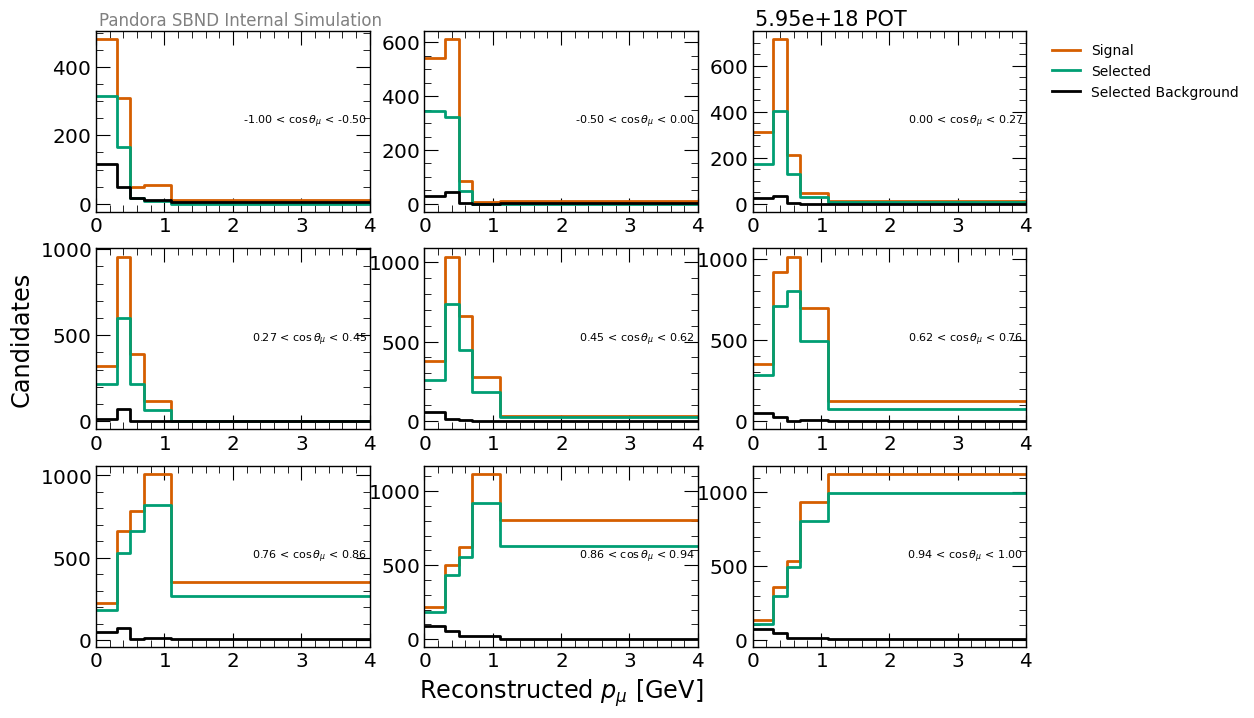

In [48]:
# fig,axs = plot_differential_hist(reco_sig_momentum,reco_sig_costheta_bin,diff_momentum_bins,genweights_sig,differential_dicts,
#   label='Signal')
# fig,axs = plot_differential_hist(reco_sel_momentum,reco_sel_costheta_bin,diff_momentum_bins,genweights_sel,differential_dicts,
#   label='Selected',fig=fig,axs=axs)
# fig,axs = plot_differential_hist(reco_sel_background_momentum,reco_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,differential_dicts,
#   label='Selected Background',fig=fig,axs=axs,xlabel=r'Reconstructed $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
fig,axs = binning2d.plot_differential_hist(reco_sig_momentum,reco_sig_costheta_bin,diff_momentum_bins,genweights_sig,differential_dicts,
  label='Signal')
fig,axs = binning2d.plot_differential_hist(reco_sel_momentum,reco_sel_costheta_bin,diff_momentum_bins,genweights_sel,differential_dicts,
  label='Selected',fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_hist(reco_sel_background_momentum,reco_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,differential_dicts,
  label='Selected Background',fig=fig,axs=axs,xlabel=r'Reconstructed $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
plotters.add_label(axs[0,0],PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=12,color='gray')
plotters.add_label(axs[0,2],POT_LABEL,where=(0.01,1.03+label_y_shift),color='black',alpha=1.,fontsize=15)
plotters.save_plot('reco_2d_costheta_momentum_signal_selected_background',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

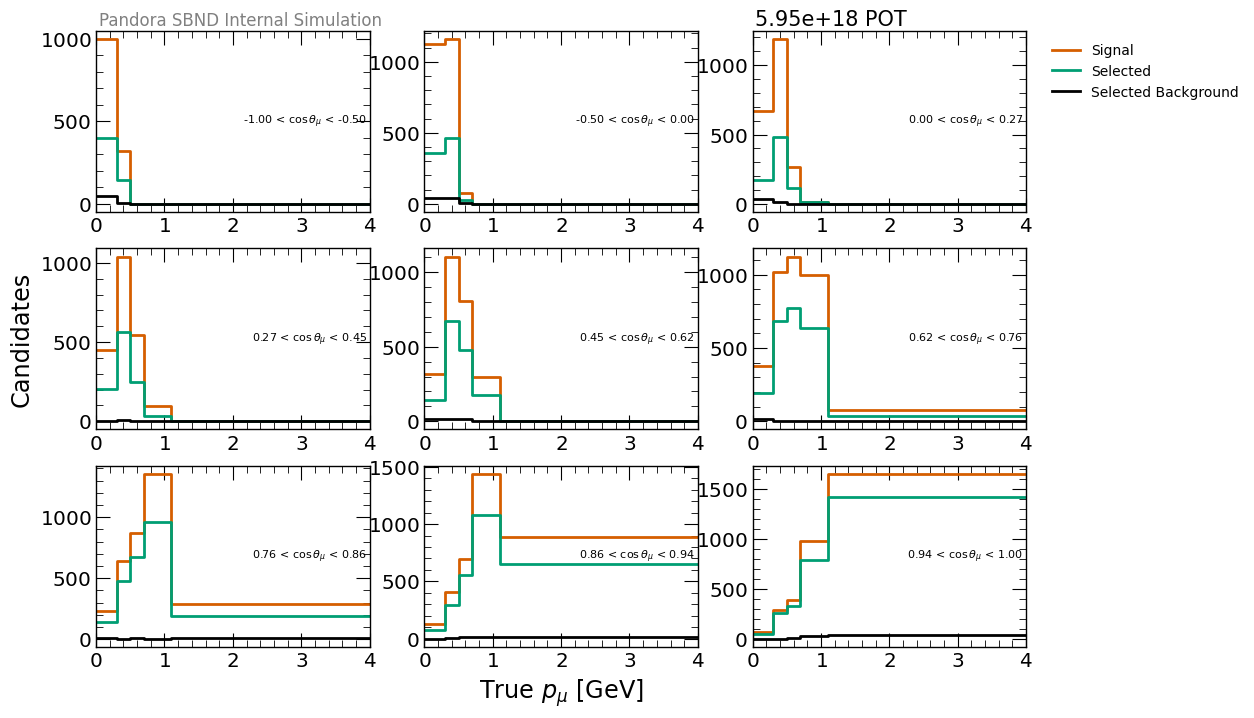

In [49]:
# fig,axs = plot_differential_hist(true_sig_momentum,true_sig_costheta_bin,diff_momentum_bins,genweights_sig,differential_dicts,
#   label='Signal')
# fig,axs = plot_differential_hist(true_sel_momentum,true_sel_costheta_bin,diff_momentum_bins,genweights_sel,differential_dicts,
#   label='Selected',fig=fig,axs=axs)
# fig,axs = plot_differential_hist(true_sel_background_momentum,true_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,differential_dicts,
#  label='Selected Background',fig=fig,axs=axs,xlabel=r'True $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
fig,axs = binning2d.plot_differential_hist(true_sig_momentum,true_sig_costheta_bin,diff_momentum_bins,genweights_sig,differential_dicts,
  label='Signal')
fig,axs = binning2d.plot_differential_hist(true_sel_momentum,true_sel_costheta_bin,diff_momentum_bins,genweights_sel,differential_dicts,
  label='Selected',fig=fig,axs=axs)
fig,axs = binning2d.plot_differential_hist(true_sel_background_momentum,true_sel_background_costheta_bin,diff_momentum_bins,genweights_sel_background,differential_dicts,
  label='Selected Background',fig=fig,axs=axs,xlabel=r'True $p_{\mu}$ [GeV]',ylabel='Candidates',legend=True,add_labels=True)
plotters.add_label(axs[0,0],PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=12,color='gray')
plotters.add_label(axs[0,2],POT_LABEL,where=(0.01,1.03+label_y_shift),color='black',alpha=1.,fontsize=15)
plotters.save_plot('true_2d_costheta_momentum_signal_selected_background',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

/tmp/ipykernel_1619/50528121.py:5: RuntimeWarning: invalid value encountered in divide
  slc_differential_eff = slc_differential_sel/slc_differential_sig


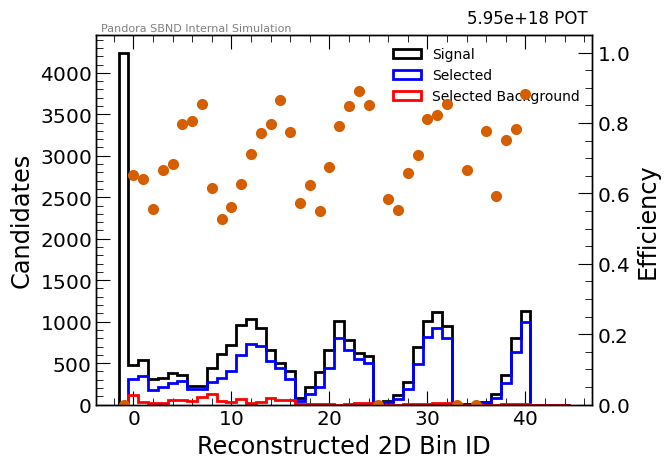

In [50]:
fig,ax = plt.subplots()
slc_differential_sig,_,_ = ax.hist(reco_sig_differential,bins=differential_edges,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_differential_sel,_,_ = ax.hist(reco_sel_differential,bins=differential_edges,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_differential_sel_background,_,_ = ax.hist(reco_sel_background_differential,bins=differential_edges,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_differential_eff = slc_differential_sel/slc_differential_sig
assert np.nanmax(slc_differential_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_differential_eff)}'
ax2 = ax.twinx()
ax2.scatter(differential_centers,slc_differential_eff,label='Efficiency')
#ax2.errorbar(differential_centers,slc_differential_eff,yerr=1/np.sqrt(slc_differential_sel),label='Efficiency',fmt='o')
ax.set_xlabel(r'Reconstructed 2D Bin ID')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('reco_differential_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

/tmp/ipykernel_1619/3868280209.py:5: RuntimeWarning: invalid value encountered in divide
  slc_differential_eff_truth = slc_differential_sel_truth/slc_differential_sig_truth


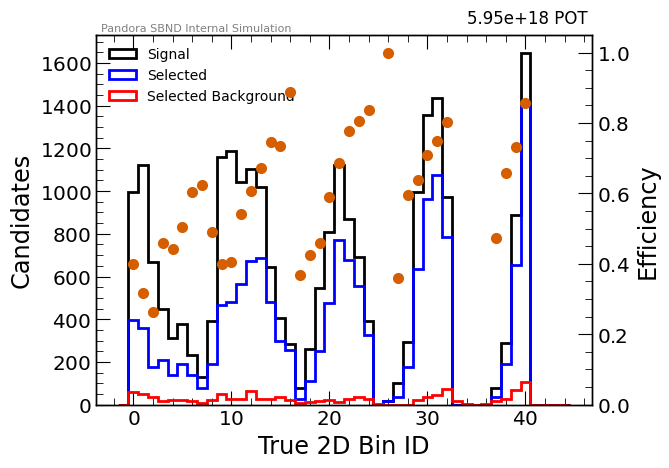

In [51]:
fig,ax = plt.subplots()
slc_differential_sig_truth,_,_ = ax.hist(true_sig_differential,bins=differential_edges,weights=genweights_sig,label='Signal',histtype='step',color='black',alpha=1.)
slc_differential_sel_truth,_,_ = ax.hist(true_sel_differential,bins=differential_edges,weights=genweights_sel,label='Selected',histtype='step',color='blue',alpha=1.)
slc_differential_sel_background_truth,_,_ = ax.hist(true_sel_background_differential,bins=differential_edges,weights=genweights_sel_background,label='Selected Background',histtype='step',color='red',alpha=1.)
slc_differential_eff_truth = slc_differential_sel_truth/slc_differential_sig_truth
assert np.nanmax(slc_differential_eff) <= 1.0, f'Efficiency is greater than 100%: {np.nanmax(slc_differential_eff)}'
ax2 = ax.twinx()
ax2.scatter(differential_centers,slc_differential_eff_truth,label='Efficiency')
#ax2.errorbar(differential_centers,slc_differential_eff_truth,yerr=1/np.sqrt(slc_differential_sel_truth),label='Efficiency',fmt='o')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel('Candidates')
ax2.set_ylim(0,1.05)
ax2.set_ylabel('Efficiency')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
ax.legend()

plotters.save_plot('truth_differential_sel_signal_eff',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

### 3.2 Smearing matrix

In [52]:
from unfolding_inputs import get_smear_matrix

In [53]:
#True vs reco costheta
slc_costheta_smearing = get_smear_matrix(true_sel_costheta,reco_sel_costheta,costheta_bins,weights=genweights_sel)
costheta_eff = get_eff(_slc_costheta_smearing, slc_costheta_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,slc_costheta_smearing.T,cmap='Blues')
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('Smearing Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('costheta_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

NameError: name '_slc_costheta_smearing' is not defined

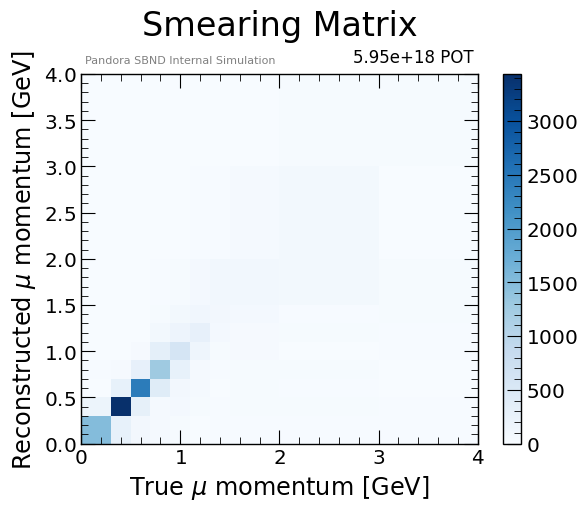

In [54]:
#True vs reco momentum
slc_momentum_smearing = get_smear_matrix(true_sel_momentum,reco_sel_momentum,momentum_bins,weights=genweights_sel)
momentum_eff = get_eff(slc_momentum_smearing, slc_momentum_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(momentum_bins,momentum_bins,slc_momentum_smearing.T,cmap='Blues')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_xlim(0,4.)
ax.set_ylim(0,4.)
ax.set_title('Smearing Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('momentum_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')


/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/unfolding/unfolding_inputs.py:79: RuntimeWarning: invalid value encountered in divide
  eff = reco_vs_true.T.sum(axis=0) / true_signal  # efficiency per truth bin


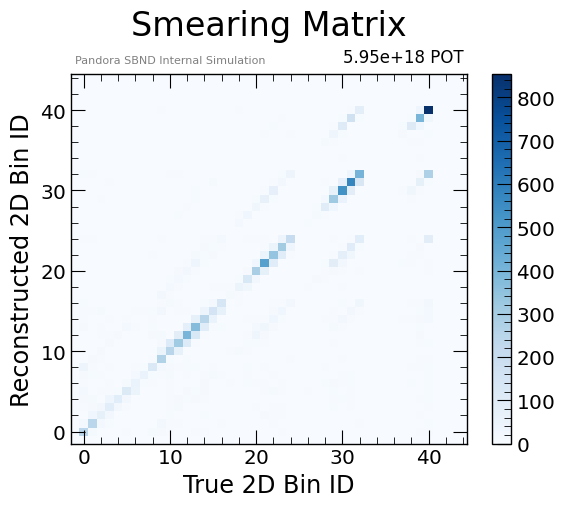

In [55]:
#True vs reco differential
slc_differential_smearing = get_smear_matrix(true_sel_differential,reco_sel_differential,differential_edges,weights=genweights_sel)
differential_eff = get_eff(slc_differential_smearing, slc_differential_sig_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(differential_edges,differential_edges,slc_differential_smearing.T,cmap='Blues')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel(r'Reconstructed 2D Bin ID')
ax.set_title('Smearing Matrix')
# ax.set_xlim(-2,10)
# ax.set_ylim(-2,10)
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('differential_smearing_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')


### 3.3 Response matrix

In [56]:
from sbnd.stats import stats

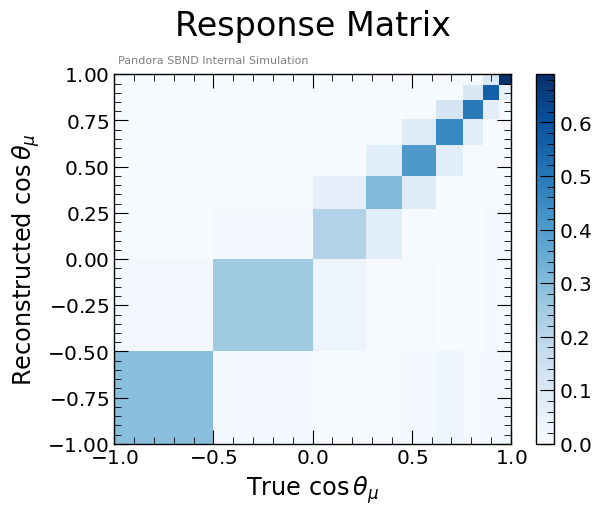

In [57]:
slc_costheta_response = stats.convert_smearing_to_response(slc_costheta_smearing,slc_costheta_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,slc_costheta_response.T,cmap='Blues')
fig.colorbar(im,ax=ax)
ax.set_xlabel(r'True $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('Response Matrix')

plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('costheta_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

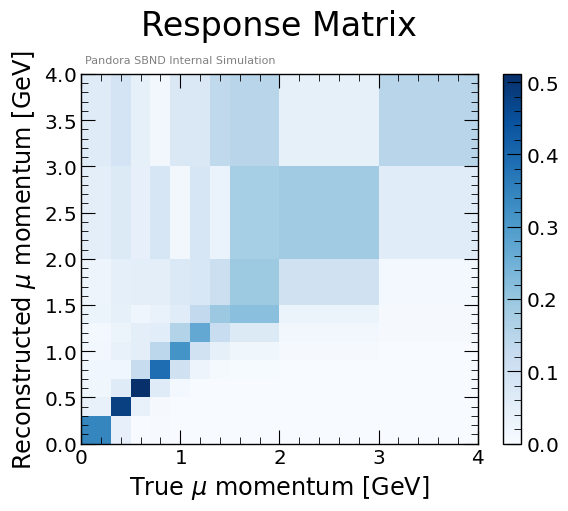

In [58]:
#Response vs reco momentum
slc_momentum_response = stats.convert_smearing_to_response(slc_momentum_smearing,slc_momentum_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(momentum_bins,momentum_bins,slc_momentum_response.T,cmap='Blues')
ax.set_xlabel(r'True $\mu$ momentum [GeV]')
ax.set_ylabel(r'Reconstructed $\mu$ momentum [GeV]')
ax.set_title('Response Matrix')
ax.set_xlim(0,4.)
ax.set_ylim(0,4.)
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('momentum_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

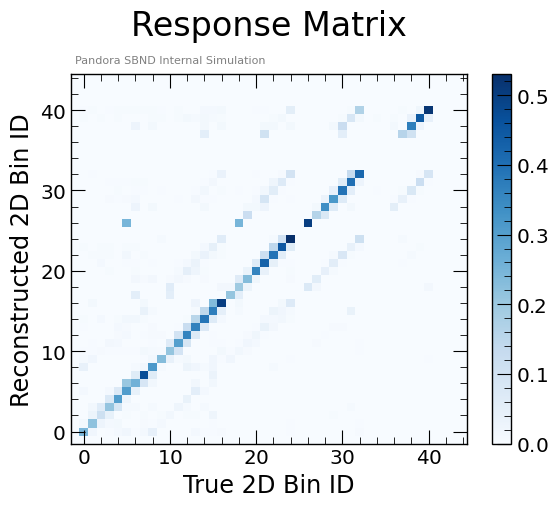

In [59]:
#Response for differential
slc_differential_response = stats.convert_smearing_to_response(slc_differential_smearing,slc_differential_eff_truth)

fig,ax = plt.subplots()
im = ax.pcolormesh(differential_edges,differential_edges,slc_differential_response.T,cmap='Blues')
ax.set_xlabel(r'True 2D Bin ID')
ax.set_ylabel(r'Reconstructed 2D Bin ID')
ax.set_title('Response Matrix')
fig.colorbar(im,ax=ax)
plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.03+label_y_shift),fontsize=8,color='gray')
#plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
plotters.save_plot('differential_response_matrix',fig=fig,folder_name=f'{PLOT_DIR}/pandora')

## 4. Flux

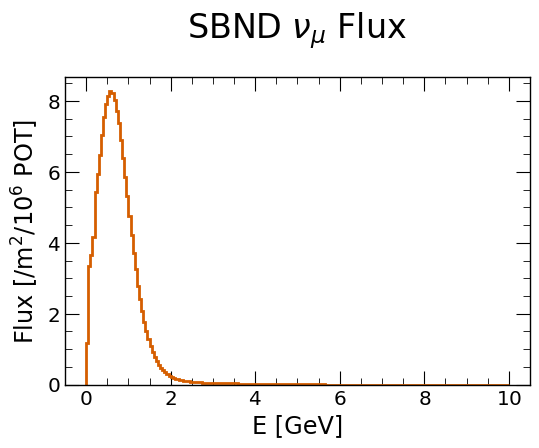

In [60]:
fig,ax = plt.subplots(figsize=(6,4))
ax.hist(bin_edges[:-1], bins=bin_edges, weights=flux_vals, histtype="step")
ax.set_xlabel("E [GeV]")
ax.set_ylabel("Flux [/m$^{2}$/10$^{6}$ POT]")
ax.set_title("SBND $\\nu_\\mu$ Flux")
fig.savefig(f'{PLOT_DIR}/flux.png')
plt.show()

## 5. $\tilde{\sigma}$ for CV

In [90]:
#Compute sigma_tilde
slc_costheta_sigma_tilde = XSEC_UNIT*(slc_costheta_response @ slc_costheta_sel_truth + slc_costheta_sel_background)
slc_momentum_sigma_tilde = XSEC_UNIT*(slc_momentum_response @ slc_momentum_sel_truth + slc_momentum_sel_background)
slc_differential_sigma_tilde = XSEC_UNIT*(slc_differential_response @ slc_differential_sel_truth + slc_differential_sel_background)

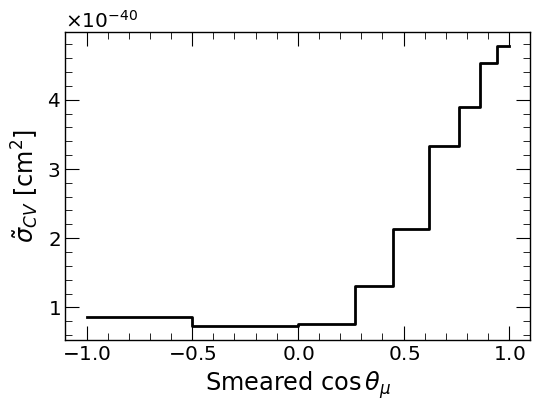

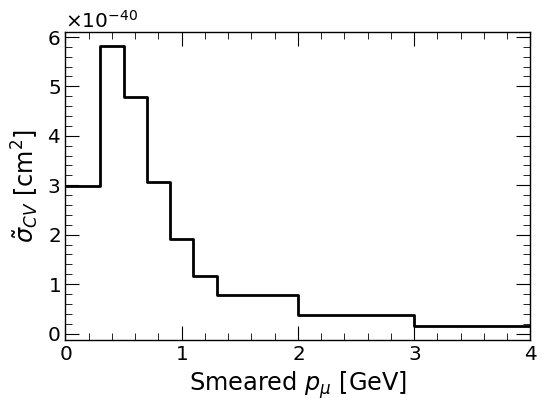

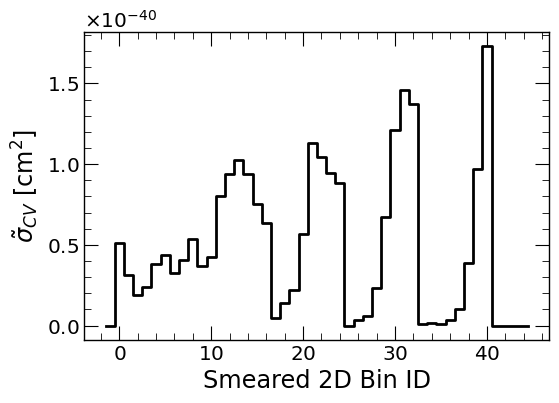

In [91]:
from sbnd.plotlibrary import makeplot
fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(costheta_bins,slc_costheta_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared $\cos\theta_{\mu}$')
plt.show()

fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(momentum_bins,slc_momentum_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared $p_{\mu}$ [GeV]')
ax.set_xlim(0,4.)
plt.show()

fig,ax = plt.subplots(figsize=(6,4))
makeplot.plot_hist_edges(differential_edges,slc_differential_sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
ax.set_ylabel(r'$\tilde{\sigma}_{CV}$ [cm$^{2}$]')
ax.set_xlabel(r'Smeared 2D Bin ID')
plt.show()

## 5. Covariance Matrices

In [64]:
#Add the stat weights, why not
slc_mc_sel_signal.add_stat_unc()
slc_mc_sel_background.add_stat_unc()

Generating event seeds:   0%|          | 0/3762 [00:00<?, ?it/s]

Generating event seeds: 100%|██████████| 3762/3762 [00:00<00:00, 111288.02it/s]


Successfully generated 3762 unique seeds


Generating event seeds: 100%|██████████| 285/285 [00:00<00:00, 106208.50it/s]


Successfully generated 285 unique seeds


Generating universes: 100%|██████████| 100/100 [00:00<00:00, 1055.35it/s]


In [297]:
from sbnd.plotlibrary import makeplot
#from sbnd.general.utils import get_sys_keydict
#Get names of each systematic
sys_col_dicts = get_sys_keydict(slc_mc_sel_signal.data.truth.keys())

In [280]:
XSEC_UNIT

2.0488476918781626e-43

In [281]:
sys_col_dicts.keys()

dict_keys(['expskin_Flux', 'horncurrent_Flux', 'kminus_Flux', 'kplus_Flux', 'kzero_Flux', 'nucleoninexsec_Flux', 'nucleonqexsec_Flux', 'nucleontotxsec_Flux', 'piminus_Flux', 'pioninexsec_Flux', 'pionqexsec_Flux', 'piontotxsec_Flux', 'piplus_Flux', 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_RPA_CCQE', 'GENIEReWeight_SBN_v1_multisim_CoulombCCQE', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC', 'GENIEReWeight_SBN_v1_multisim_NormNCMEC', 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisim_RDecBR1eta', 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MaNCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC1pi', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC2pi', 'GENIEReWeight_SBN_v

In [350]:
slc_costheta_sel_background

array([197.67850929,  79.47372704,  64.56827431,  96.35776513,
        82.44160508,  89.3996851 , 148.01568771, 187.75255123,
       151.00008138])

In [436]:
from sbnd.cafclasses.systematics import Systematics
%load_ext autoreload
%autoreload 2

systematics = Systematics(slc_mc_sel_signal.data.truth.keys(),costheta_bins, momentum_bins, differential_edges,
                 slc_costheta_sigma_tilde, slc_momentum_sigma_tilde, slc_differential_sigma_tilde,
                 slc_costheta_sel, slc_momentum_sel, slc_differential_sel,
                 slc_costheta_sel_background, slc_momentum_sel_background, slc_differential_sel_background,
                 slc_costheta_sel_truth, slc_momentum_sel_truth, slc_differential_sel_truth,
                 slc_costheta_response, slc_momentum_response, slc_differential_response,
                 slc_costheta_eff_truth, slc_momentum_eff_truth, slc_differential_eff_truth,
                 XSEC_UNIT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [437]:
systematics.process_systematics(slc_mc_signal.data, slc_mc_sel_signal.data,
                           genweights_sig, genweights_sel, genweights_sel_background,
                           true_sig_costheta, true_sel_costheta, true_sel_background_costheta,
                           reco_sel_costheta, reco_sel_background_costheta,
                           true_sig_momentum, true_sel_momentum, true_sel_background_momentum,
                           reco_sel_momentum, reco_sel_background_momentum,
                           true_sig_differential, true_sel_differential, true_sel_background_differential,
                           reco_sel_differential, reco_sel_background_differential,progress_bar=True)

  0%|          | 0/62 [00:00<?, ? goomba/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/cafclasses/systematics.py:439: RuntimeWarning: invalid value encountered in divide
  _differential_smearing = _get_smear_matrix(
100%|██████████| 62/62 [03:51<00:00,  3.74s/ goomba]


In [438]:
systematics.compute_covariances()
systematics.combine_summaries()

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:35: RuntimeWarning: divide by zero encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:35: RuntimeWarning: invalid value encountered in divide
  diff_fractional = diff / denom
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:37: RuntimeWarning: invalid value encountered in matmul
  fractional_cov = diff_fractional.T @ diff_fractional / n_universes
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:50: RuntimeWarning: invalid value encountered in divide
  if (eigval_ratios < -tol_ratio).any():
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:74: RuntimeWarning: invalid value encountered in scalar divide
  
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/s

In [439]:

# #Each universe will have a response matrix
# #makeplot.plot_hist_edges(costheta_bins,slc_costheta_sig,None,ax=ax,color='black',label='Signal',alpha=1.)
# for i,key in tqdm(enumerate(sys_col_dicts.keys()),total=len(sys_col_dicts.keys()),unit=' goomba'):
#   #if key != 'stat': continue
#   cols = sys_col_dicts[key]['cols']
#   col_names = sys_col_dicts[key]['col_names']
#   # Store the histograms for each universe, then compute the covariance, correlation, fractional covariance, and fractional uncertainty
#   sys_col_dicts[key] = {
#     'cols' : cols,
#     'col_names' : col_names,
#     'type' : sys_col_dicts[key]['type'],
#     'name' : sys_col_dicts[key]['name'],
#     'variation' : sys_col_dicts[key]['variation'],
#     #Sigma tilde
#     'costheta_sigma_tilde' : [],
#     'momentum_sigma_tilde' : [],
#     'differential_sigma_tilde' : [],
#     #Reco event rate
#     'costheta_sel' : [],
#     'momentum_sel' : [],
#     'differential_sel' : [],
#     #Xsec covariance
#     'costheta_xsec_cov' : None,
#     'momentum_xsec_cov' : None,
#     'differential_xsec_cov' : None,
#     #Event covariance
#     'costheta_event_cov' : None,
#     'momentum_event_cov' : None,
#     'differential_event_cov' : None,
#     #Xsec correlation
#     'costheta_xsec_corr' : None,
#     'momentum_xsec_corr' : None,
#     'differential_xsec_corr' : None,
#     #Event correlation
#     'costheta_event_corr' : None,
#     'momentum_event_corr' : None,
#     'differential_event_corr' : None,
#     #Xsec fractional covariance
#     'costheta_xsec_fraccov' : None,
#     'momentum_xsec_fraccov' : None,
#     'differential_xsec_fraccov' : None,
#     #Event fractional covariance
#     'costheta_event_fraccov' : None,
#     'momentum_event_fraccov' : None,
#     'differential_event_fraccov' : None,
#     #Xsec fractional uncertainty
#     'costheta_xsec_fracunc' : None,
#     'momentum_xsec_fracunc' : None,
#     'differential_xsec_fracunc' : None,
#     #Event fractional uncertainty
#     'costheta_event_fracunc' : None,
#     'momentum_event_fracunc' : None,
#     'differential_event_fracunc' : None,
#     #Event total uncertainty
#     'costheta_event_totalunc' : None,
#     'momentum_event_totalunc' : None,
#     'differential_event_totalunc' : None,
#     #Xsec total uncertainty
#     'costheta_xsec_totalunc' : None,
#     'momentum_xsec_totalunc' : None,
#     'differential_xsec_totalunc' : None
#   }
#   #if i != 14: continue #just use a small one for now
#   for j,(col,col_name) in enumerate(zip(cols,col_names)):
#     if '_cv' in col_name and sys_col_dicts[key]['variation'] == 'multisigma': 
#       print(f'skipping {col_name} because it is a {sys_col_dicts[key]["variation"]} variation')
#       continue

#     #Get the distribution for selected and signal - also the reco quantities for event level distributions
#     # - Costheta
#     # -- True
#     _slc_costheta_sig_truth,_ = np.histogram(true_sig_costheta,bins=costheta_bins,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_costheta_sel_truth,_ = np.histogram(true_sel_costheta,bins=costheta_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_costheta_sel_background_truth,_ = np.histogram(true_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background)

#     # -- Reco
#     _slc_costheta_sig,_ = np.histogram(true_sig_costheta,bins=costheta_bins,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_costheta_sel,_ = np.histogram(reco_sel_costheta,bins=costheta_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_costheta_sel_background,_ = np.histogram(reco_sel_background_costheta,bins=costheta_bins,weights=genweights_sel_background)

#     # - Momentum
#     # -- True
#     _slc_momentum_sig_truth,_ = np.histogram(true_sig_momentum,bins=momentum_bins,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_momentum_sel_truth,_ = np.histogram(true_sel_momentum,bins=momentum_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_momentum_sel_background_truth,_ = np.histogram(true_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background)
#     # -- Reco
#     _slc_momentum_sig,_ = np.histogram(true_sig_momentum,bins=momentum_bins,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_momentum_sel,_ = np.histogram(reco_sel_momentum,bins=momentum_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_momentum_sel_background,_ = np.histogram(reco_sel_background_momentum,bins=momentum_bins,weights=genweights_sel_background)

#     # - Differential
#     # -- True
#     _slc_differential_sig_truth,_ = np.histogram(true_sig_differential,bins=differential_edges,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_differential_sel_truth,_ = np.histogram(true_sel_differential,bins=differential_edges,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_differential_sel_background_truth,_ = np.histogram(true_sel_background_differential,bins=differential_edges,weights=genweights_sel_background)
    
#     # -- Reco
#     _slc_differential_sig,_ = np.histogram(true_sig_differential,bins=differential_edges,weights=genweights_sig*slc_mc_signal.data[col])
#     _slc_differential_sel,_ = np.histogram(reco_sel_differential,bins=differential_edges,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_differential_sel_background,_ = np.histogram(reco_sel_background_differential,bins=differential_edges,weights=genweights_sel_background)

#     #Get the efficiencies
#     # -- True
#     _slc_costheta_eff_truth = _slc_costheta_sel_truth/_slc_costheta_sig_truth
#     _slc_momentum_eff_truth = _slc_momentum_sel_truth/_slc_momentum_sig_truth
#     _slc_differential_eff_truth = _slc_differential_sel_truth/_slc_differential_sig_truth
#     # -- Reco
#     _slc_costheta_eff_reco = _slc_costheta_sel/_slc_costheta_sig
#     _slc_momentum_eff_reco = _slc_momentum_sel/_slc_momentum_sig
#     _slc_differential_eff_reco = _slc_differential_sel/_slc_differential_sig

#     #Get the smearing and response matrices
#     # - For uncertainties on the xsec, we use the efficiency of the universe
#     _slc_costheta_smearing = get_smear_matrix(true_sel_costheta,reco_sel_costheta,costheta_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_momentum_smearing = get_smear_matrix(true_sel_momentum,reco_sel_momentum,momentum_bins,weights=genweights_sel*slc_mc_sel_signal.data[col])
#     _slc_differential_smearing = get_smear_matrix(true_sel_differential,reco_sel_differential,differential_edges,weights=genweights_sel*slc_mc_sel_signal.data[col])

#     # Use universe CV for systematics in denominator except for xsec uncertainties, which uses the universe CV
#     if 'GENIE' in key: #xsec treatment
#       _slc_differential_response = stats.convert_smearing_to_response(_slc_differential_smearing,_slc_differential_eff_truth)
#       _slc_momentum_response = stats.convert_smearing_to_response(_slc_momentum_smearing,_slc_momentum_eff_truth)
#       _slc_costheta_response = stats.convert_smearing_to_response(_slc_costheta_smearing,_slc_costheta_eff_truth)
#     else:
#       _slc_differential_response = stats.convert_smearing_to_response(_slc_differential_smearing,slc_differential_eff_truth)
#       _slc_momentum_response = stats.convert_smearing_to_response(_slc_momentum_smearing,slc_momentum_eff_truth)
#       _slc_costheta_response = stats.convert_smearing_to_response(_slc_costheta_smearing,slc_costheta_eff_truth)
#     # plt.imshow(_slc_differential_response-slc_differential_response)
#     # plt.colorbar()
#     # plt.show()
#     #break

#     #Compute sigma_tilde
#     _slc_costheta_sigma_tilde = XSEC_UNIT*(_slc_costheta_response @ slc_costheta_sel_truth + _slc_costheta_sel_background)
#     _slc_momentum_sigma_tilde = XSEC_UNIT*(_slc_momentum_response @ slc_momentum_sel_truth + _slc_momentum_sel_background)
#     _slc_differential_sigma_tilde = XSEC_UNIT*(_slc_differential_response @ slc_differential_sel_truth + _slc_differential_sel_background)
    
#     #Store those suckers in the dictionary
#     # Sigma tilde - for xsec covariance
#     sys_col_dicts[key]['costheta_sigma_tilde'].append(_slc_costheta_sigma_tilde)
#     sys_col_dicts[key]['momentum_sigma_tilde'].append(_slc_momentum_sigma_tilde)
#     sys_col_dicts[key]['differential_sigma_tilde'].append(_slc_differential_sigma_tilde)
#     # Reco event rate - for event level covariance
#     sys_col_dicts[key]['costheta_sel'].append(_slc_costheta_sel+_slc_costheta_sel_background)
#     sys_col_dicts[key]['momentum_sel'].append(_slc_momentum_sel+_slc_momentum_sel_background)
#     sys_col_dicts[key]['differential_sel'].append(_slc_differential_sel+_slc_differential_sel_background)
#     # sys_col_dicts[key][2].append(_slc_costheta_response)
#     # sys_col_dicts[key][3].append(_slc_momentum_response)
#     # sys_col_dicts[key][4].append(_slc_differential_response)
#     #break
#   #Ok now we can compute the covariance matrices
#   # -Costheta
#   # -- Xsec
#   _xsec_cov,_xsec_frac,_xsec_corr,_xsec_fracunc = stats.construct_covariance(slc_costheta_sigma_tilde,sys_col_dicts[key]['costheta_sigma_tilde'],assert_cov=False)
#   sys_col_dicts[key]['costheta_xsec_cov'] = _xsec_cov
#   sys_col_dicts[key]['costheta_xsec_fraccov'] = _xsec_frac
#   sys_col_dicts[key]['costheta_xsec_corr'] = _xsec_corr
#   sys_col_dicts[key]['costheta_xsec_fracunc'] = _xsec_fracunc
#   _xsec_total_unc = stats.get_total_unc(slc_costheta_sigma_tilde,sys_col_dicts[key]['costheta_xsec_fracunc'])
#   sys_col_dicts[key]['costheta_xsec_totalunc'] = _xsec_total_unc
#   # -- Event
#   _cov,_frac,_corr,_fracunc = stats.construct_covariance(slc_costheta_sel+slc_costheta_sel_background,sys_col_dicts[key]['costheta_sel'],assert_cov=False)
#   sys_col_dicts[key]['costheta_event_cov'] = _cov
#   sys_col_dicts[key]['costheta_event_fraccov'] = _frac
#   sys_col_dicts[key]['costheta_event_corr'] = _corr
#   sys_col_dicts[key]['costheta_event_fracunc'] = _fracunc
#   _total_unc = stats.get_total_unc(slc_costheta_sel+slc_costheta_sel_background,sys_col_dicts[key]['costheta_event_fracunc'])
#   sys_col_dicts[key]['costheta_event_totalunc'] = _total_unc
  

#   # -Momentum
#   # -- Xsec
#   _xsec_cov,_xsec_frac,_xsec_corr,_xsec_fracunc = stats.construct_covariance(slc_momentum_sigma_tilde,sys_col_dicts[key]['momentum_sigma_tilde'],assert_cov=False)
#   sys_col_dicts[key]['momentum_xsec_cov'] = _xsec_cov
#   sys_col_dicts[key]['momentum_xsec_fraccov'] = _xsec_frac
#   sys_col_dicts[key]['momentum_xsec_corr'] = _xsec_corr
#   sys_col_dicts[key]['momentum_xsec_fracunc'] = _xsec_fracunc
#   _xsec_total_unc = stats.get_total_unc(slc_momentum_sigma_tilde,sys_col_dicts[key]['momentum_xsec_fracunc'])
#   sys_col_dicts[key]['momentum_xsec_totalunc'] = _xsec_total_unc
#   # -- Event
#   _cov,_frac,_corr,_fracunc = stats.construct_covariance(slc_momentum_sel+slc_momentum_sel_background,sys_col_dicts[key]['momentum_sel'],assert_cov=False)
#   sys_col_dicts[key]['momentum_event_cov'] = _cov
#   sys_col_dicts[key]['momentum_event_fraccov'] = _frac
#   sys_col_dicts[key]['momentum_event_corr'] = _corr
#   sys_col_dicts[key]['momentum_event_fracunc'] = _fracunc
#   _total_unc = stats.get_total_unc(slc_momentum_sel+slc_momentum_sel_background,sys_col_dicts[key]['momentum_event_fracunc'])
#   sys_col_dicts[key]['momentum_event_totalunc'] = _total_unc

#   # -Differential
#   # -- Xsec
#   _xsec_cov,_xsec_frac,_xsec_corr,_xsec_fracunc = stats.construct_covariance(slc_differential_sigma_tilde,sys_col_dicts[key]['differential_sigma_tilde'],assert_cov=False)
#   sys_col_dicts[key]['differential_xsec_cov'] = _xsec_cov
#   sys_col_dicts[key]['differential_xsec_fraccov'] = _xsec_frac
#   sys_col_dicts[key]['differential_xsec_corr'] = _xsec_corr
#   sys_col_dicts[key]['differential_xsec_fracunc'] = _xsec_fracunc
#   _xsec_total_unc = stats.get_total_unc(slc_differential_sigma_tilde,sys_col_dicts[key]['differential_xsec_fracunc'])
#   sys_col_dicts[key]['differential_xsec_totalunc'] = _xsec_total_unc
#   # -- Event
#   _cov,_frac,_corr,_fracunc = stats.construct_covariance(slc_differential_sel+slc_differential_sel_background,sys_col_dicts[key]['differential_sel'],assert_cov=False)
#   sys_col_dicts[key]['differential_event_cov'] = _cov
#   sys_col_dicts[key]['differential_event_fraccov'] = _frac
#   sys_col_dicts[key]['differential_event_corr'] = _corr
#   sys_col_dicts[key]['differential_event_fracunc'] = _fracunc
#   _total_unc = stats.get_total_unc(slc_differential_sel+slc_differential_sel_background,sys_col_dicts[key]['differential_event_fracunc'])
#   sys_col_dicts[key]['differential_event_totalunc'] = _total_unc
#   #break


In [ ]:
#_total_unc,_xsec_total_unc

In [ ]:
# for i,k in enumerate(list(sys_col_dicts.keys())):
#   if 'rpa_ccqe' in k.lower():
#     print(i,k)
#     break

In [ ]:
#from sbnd.stats.stats import construct_covariance,construct_correlation_matrix,get_fractional_uncertainty

In [ ]:
# #Create combined covariance matrices
# _dict_template = {
#     'cols' : None,
#     'col_names' : None,
#     'type' : None,
#     'name' : None,
#     #Sigma tilde
#     'costheta_sigma_tilde' : None,
#     'momentum_sigma_tilde' : None,
#     'differential_sigma_tilde' : None,
#     #Reco event rate
#     'costheta_sel' : None,
#     'momentum_sel' : None,
#     'differential_sel' : None,
#     #Xsec covariance
#     'costheta_xsec_cov' : None,
#     'momentum_xsec_cov' : None,
#     'differential_xsec_cov' : None,
#     #Event covariance
#     'costheta_event_cov' : None,
#     'momentum_event_cov' : None,
#     'differential_event_cov' : None,
#     #Xsec correlation
#     'costheta_xsec_corr' : None,
#     'momentum_xsec_corr' : None,
#     'differential_xsec_corr' : None,
#     #Event correlation
#     'costheta_event_corr' : None,
#     'momentum_event_corr' : None,
#     'differential_event_corr' : None,
#     #Xsec fractional covariance
#     'costheta_xsec_fraccov' : None,
#     'momentum_xsec_fraccov' : None,
#     'differential_xsec_fraccov' : None,
#     #Event fractional covariance
#     'costheta_event_fraccov' : None,
#     'momentum_event_fraccov' : None,
#     'differential_event_fraccov' : None,
#     #Xsec fractional uncertainty
#     'costheta_xsec_fracunc' : None,
#     'momentum_xsec_fracunc' : None,
#     'differential_xsec_fracunc' : None,
#     #Event fractional uncertainty
#     'costheta_event_fracunc' : None,
#     'momentum_event_fracunc' : None,
#     'differential_event_fracunc' : None
#   }
# #Append summary keys into dictionary
# summary_keys = ['xsec','flux','total']
# for k in summary_keys:
#   sys_col_dicts[k] = _dict_template.copy()
#   sys_col_dicts[k]['cols'] = None
#   sys_col_dicts[k]['col_names'] = None
#   sys_col_dicts[k]['type'] = k
#   sys_col_dicts[k]['name'] = k
#   #Event covariance
#   sys_col_dicts[k]['costheta_event_cov'] = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
#   sys_col_dicts[k]['momentum_event_cov'] = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
#   sys_col_dicts[k]['differential_event_cov'] = np.zeros((len(differential_edges)-1,len(differential_edges)-1))
#   #Xsec Covariance
#   sys_col_dicts[k]['costheta_xsec_cov'] = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
#   sys_col_dicts[k]['momentum_xsec_cov'] = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
#   sys_col_dicts[k]['differential_xsec_cov'] = np.zeros((len(differential_edges)-1,len(differential_edges)-1))
#   #Xsec fractional covariance
#   sys_col_dicts[k]['costheta_xsec_fraccov'] = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
#   sys_col_dicts[k]['momentum_xsec_fraccov'] = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
#   sys_col_dicts[k]['differential_xsec_fraccov'] = np.zeros((len(differential_edges)-1,len(differential_edges)-1))
#   #Event fractional covariance
#   sys_col_dicts[k]['costheta_event_fraccov'] = np.zeros((len(costheta_bins)-1,len(costheta_bins)-1))
#   sys_col_dicts[k]['momentum_event_fraccov'] = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
#   sys_col_dicts[k]['differential_event_fraccov'] = np.zeros((len(differential_edges)-1,len(differential_edges)-1))
# #Fill them in - we just need the covariance matrices and fractional uncertainties
# for i,key in tqdm(enumerate(sys_col_dicts.keys()),total=len(sys_col_dicts.keys()),unit=' goomba'):
#   #We can just add covariance and fractional covariance matrices. Compute correlatation and fractional uncertainty at the end
#   if sys_col_dicts[key]['type'] == sys_col_dicts[key]['name']: continue #Don't combine these
#   for sk in summary_keys:
#     if (sys_col_dicts[key]['type'] == sk) or (sk == 'total'):
#       #Event covariance
#       sys_col_dicts[sk]['costheta_event_cov'] += sys_col_dicts[key]['costheta_event_cov']
#       sys_col_dicts[sk]['momentum_event_cov'] += sys_col_dicts[key]['momentum_event_cov']
#       sys_col_dicts[sk]['differential_event_cov'] += sys_col_dicts[key]['differential_event_cov']
#       #XSec covariance
#       sys_col_dicts[sk]['costheta_xsec_cov'] += sys_col_dicts[key]['costheta_xsec_cov']
#       sys_col_dicts[sk]['momentum_xsec_cov'] += sys_col_dicts[key]['momentum_xsec_cov']
#       sys_col_dicts[sk]['differential_xsec_cov'] += sys_col_dicts[key]['differential_xsec_cov']
#       #Event fractional covariance
#       sys_col_dicts[sk]['costheta_event_fraccov'] += sys_col_dicts[key]['costheta_event_fraccov']
#       sys_col_dicts[sk]['momentum_event_fraccov'] += sys_col_dicts[key]['momentum_event_fraccov']
#       sys_col_dicts[sk]['differential_event_fraccov'] += sys_col_dicts[key]['differential_event_fraccov']
#       #Xsec fractional covariance
#       sys_col_dicts[sk]['costheta_xsec_fraccov'] += sys_col_dicts[key]['costheta_xsec_fraccov']
#       sys_col_dicts[sk]['momentum_xsec_fraccov'] += sys_col_dicts[key]['momentum_xsec_fraccov']
#       sys_col_dicts[sk]['differential_xsec_fraccov'] += sys_col_dicts[key]['differential_xsec_fraccov']
# #Finally, construct the fracitonal uncertainties and correlation matrices from the covariance matrices
# for sk in summary_keys:
#   #Event fractional uncertainty
#   sys_col_dicts[sk]['costheta_event_fracunc'] = get_fractional_uncertainty(slc_costheta_sel+slc_costheta_sel_background,sys_col_dicts[sk]['costheta_event_cov'])
#   sys_col_dicts[sk]['momentum_event_fracunc'] = get_fractional_uncertainty(slc_momentum_sel+slc_momentum_sel_background,sys_col_dicts[sk]['momentum_event_cov'])
#   sys_col_dicts[sk]['differential_event_fracunc'] = get_fractional_uncertainty(slc_differential_sel+slc_differential_sel_background,sys_col_dicts[sk]['differential_event_cov'])
#   #Xsec fractional uncertainty
#   sys_col_dicts[sk]['costheta_xsec_fracunc'] = get_fractional_uncertainty(slc_costheta_sigma_tilde,sys_col_dicts[sk]['costheta_xsec_cov'])
#   sys_col_dicts[sk]['momentum_xsec_fracunc'] = get_fractional_uncertainty(slc_momentum_sigma_tilde,sys_col_dicts[sk]['momentum_xsec_cov'])
#   sys_col_dicts[sk]['differential_xsec_fracunc'] = get_fractional_uncertainty(slc_differential_sigma_tilde,sys_col_dicts[sk]['differential_xsec_cov'])
#   #Event correlation
#   sys_col_dicts[sk]['costheta_event_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['costheta_event_cov'])
#   sys_col_dicts[sk]['momentum_event_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['momentum_event_cov'])
#   sys_col_dicts[sk]['differential_event_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['differential_event_cov'])
#   #Xsec correlation
#   sys_col_dicts[sk]['costheta_xsec_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['costheta_xsec_cov'])
#   sys_col_dicts[sk]['momentum_xsec_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['momentum_xsec_cov'])
#   sys_col_dicts[sk]['differential_xsec_corr'],_ = construct_correlation_matrix(sys_col_dicts[sk]['differential_xsec_cov'])
#   #Event total uncertainty
#   sys_col_dicts[sk]['costheta_event_totalunc'] = stats.get_total_unc(slc_costheta_sel+slc_costheta_sel_background,sys_col_dicts[sk]['costheta_event_fracunc'])
#   sys_col_dicts[sk]['momentum_event_totalunc'] = stats.get_total_unc(slc_momentum_sel+slc_momentum_sel_background,sys_col_dicts[sk]['momentum_event_fracunc'])
#   sys_col_dicts[sk]['differential_event_totalunc'] = stats.get_total_unc(slc_differential_sel+slc_differential_sel_background,sys_col_dicts[sk]['differential_event_fracunc'])
#   #Xsec total uncertainty
#   sys_col_dicts[sk]['costheta_xsec_totalunc'] = stats.get_total_unc(slc_costheta_sigma_tilde,sys_col_dicts[sk]['costheta_xsec_fracunc'])
#   sys_col_dicts[sk]['momentum_xsec_totalunc'] = stats.get_total_unc(slc_momentum_sigma_tilde,sys_col_dicts[sk]['momentum_xsec_fracunc'])
#   sys_col_dicts[sk]['differential_xsec_totalunc'] = stats.get_total_unc(slc_differential_sigma_tilde,sys_col_dicts[sk]['differential_xsec_fracunc'])


100%|██████████| 65/65 [00:00<00:00, 24160.74 goomba/s]


In [287]:
stats.get_total_unc(slc_costheta_sel+slc_costheta_sel_background,sys_col_dicts['flux']['costheta_event_fracunc'])*100,stats.get_total_unc(slc_costheta_sigma_tilde,sys_col_dicts['flux']['costheta_xsec_fracunc'])*100

(6.273565403516345, 0.6722354482905751)

In [ ]:
#sys_col_dicts['flux']['costheta_event_fracunc']*100,sys_col_dicts['flux']['costheta_xsec_fracunc']*100

KeyError: 'flux'

In [289]:
#slc_costheta_sigma_tilde/XSEC_UNIT,sys_col_dicts['flux']['costheta_xsec_cov']/(XSEC_UNIT**2)

In [323]:
systematics.systematics.keys()

dict_keys(['expskin_Flux', 'horncurrent_Flux', 'kminus_Flux', 'kplus_Flux', 'kzero_Flux', 'nucleoninexsec_Flux', 'nucleonqexsec_Flux', 'nucleontotxsec_Flux', 'piminus_Flux', 'pioninexsec_Flux', 'pionqexsec_Flux', 'piontotxsec_Flux', 'piplus_Flux', 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape', 'GENIEReWeight_SBN_v1_multisim_RPA_CCQE', 'GENIEReWeight_SBN_v1_multisim_CoulombCCQE', 'GENIEReWeight_SBN_v1_multisim_NormCCMEC', 'GENIEReWeight_SBN_v1_multisim_NormNCMEC', 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC', 'GENIEReWeight_SBN_v1_multisim_RDecBR1gamma', 'GENIEReWeight_SBN_v1_multisim_RDecBR1eta', 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi', 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad', 'GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MaNCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvNCRES', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC1pi', 'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC2pi', 'GENIEReWeight_SBN_v

In [330]:
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/2026_01_06'

In [440]:
figs = systematics.plot_covariance_matrices('xsec',plot_dir=f'{PLOT_DIR}/pandora/syst')

In [356]:
figs['costheta_xsec_cov'][0].show()

In [ ]:
# for key in sys_col_dicts.keys():
#   if key != 'xsec': continue
#   sys_col_dict = sys_col_dicts[key]
#   hist2dkeys = [k for k in sys_col_dict.keys() if 'corr' in k or 'cov' in k]
#   #hist2dkeys = []
#   histkeys = [k for k in sys_col_dict.keys() if 'sigma_tilde' in k]
#   #Make plots if requested
#   for plotkey in hist2dkeys:
#     subfolder = ''
#     #Get type of plot
#     if 'fraccov' in plotkey:
#       cmap = 'viridis'
#       subfolder += 'fraccov'
#     elif 'cov' in plotkey:
#       cmap = 'inferno'
#       subfolder = 'cov'
#     elif 'corr' in plotkey:
#       cmap = 'cividis'
#       subfolder += 'corr'
#     #Get variable plotted
#     set_axlims = False
#     if 'costheta' in plotkey:
#       axlabel = r'Reconstructed $\cos\theta_{\mu}$'
#       bins = costheta_bins
#     elif 'momentum' in plotkey:
#       axlabel = r'Reconstructed $p_{\mu}$ (GeV)'
#       set_axlims = True
#       bins = momentum_bins
#     elif 'differential' in plotkey:
#       axlabel = r'Reconstructed 2D Bin ID'
#       bins = differential_edges
    
#     #name = subfolder.replace('/','_')
#     title = (sys_col_dict['name'] + ' ' + plotkey.replace('_',' '))
#     name = title.replace(' ','_')
    
#     fig,ax = plt.subplots()
#     ax.set_title(title)
#     im = ax.pcolormesh(bins,bins,sys_col_dict[plotkey],cmap=cmap)
#     ax.set_xlabel(axlabel)
#     ax.set_ylabel(axlabel)
#     fig.colorbar(im,ax=ax)
#     if set_axlims:
#       ax.set_xlim(0,4.)
#       ax.set_ylim(0,4.)
#     plotters.save_plot(name,fig=fig,folder_name=f'{PLOT_DIR}/{subfolder}')
#     plt.close()
#     #break
#   for plotkey in histkeys:
#     if sys_col_dict[plotkey] == None: continue
#     subfolder = 'dist'
#     #Get variable plotted
#     set_xlim = False
#     if 'costheta' in plotkey:
#       axlabel = r'Reconstructed $\cos\theta_{\mu}$'
#       bins = costheta_bins
#       sigma_tilde = slc_costheta_sigma_tilde
#     elif 'momentum' in plotkey:
#       axlabel = r'Reconstructed $p_{\mu}$ (GeV)'
#       set_xlim = True
#       bins = momentum_bins
#       sigma_tilde = slc_momentum_sigma_tilde
#     elif 'differential' in plotkey:
#       axlabel = r'Reconstructed 2D Bin ID'
#       bins = differential_edges
#       sigma_tilde = slc_differential_sigma_tilde
    
#     title = (sys_col_dict['name'] + ' ' + plotkey.replace('_',' '))
#     name = title.replace(' ','_')

#     fig,ax = plt.subplots()
#     makeplot.plot_hist_edges(bins,sigma_tilde,None,ax=ax,color='black',label='Signal',alpha=1.)
#     for dist in sys_col_dict[plotkey]:
#       makeplot.plot_hist_edges(bins,dist,None,ax=ax,color='blue',label=None,alpha=1./len(sys_col_dict[plotkey]))
#     ax.legend()
#     ax.set_xlabel(axlabel)
#     ax.set_ylabel(r'$\tilde{\sigma}$')
#     ax.set_title(title)
#     if set_xlim:
#       ax.set_xlim(0,4.)
#     plotters.save_plot(name,fig=fig,folder_name=f'{PLOT_DIR}/{subfolder}')
#     plt.close()
#     #break

### 5.4 Detector

In [218]:
#Load detector uncertainty

# - PDS
pds_var_cov = np.loadtxt(f'{DETVAR_DIR}/reco_costheta_pds_tot_cov_xsecunit.txt')
pds_var_cov_noscale = np.loadtxt(f'{DETVAR_DIR}/reco_costheta_pds_tot_cov_noscale.txt')
fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,pds_var_cov,cmap='Blues')
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('PDS Uncertainty')
fig.colorbar(im,ax=ax)

sce_var_cov = np.loadtxt(f'{DETVAR_DIR}/reco_costheta_sce_tot_cov_xsecunit.txt')
sce_var_cov_noscale = np.loadtxt(f'{DETVAR_DIR}/reco_costheta_sce_tot_cov_noscale.txt')
fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,sce_var_cov,cmap='Blues')
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('SCE Uncertainty')
fig.colorbar(im,ax=ax)

# -total detvar
slc_total_detvar_costheta_cov = pds_var_cov + sce_var_cov
slc_total_detvar_costheta_cov_noscale = pds_var_cov_noscale + sce_var_cov_noscale

fig,ax = plt.subplots()
im = ax.pcolormesh(costheta_bins,costheta_bins,slc_total_detvar_costheta_cov,cmap='Blues')
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_title('Total Detector Uncertainty')
fig.colorbar(im,ax=ax)
#plotters.save_plot('total_detvar_costheta',fig=fig,folder_name=f'{PLOT_DIR}/pandora/cov')

NameError: name 'DETVAR_DIR' is not defined

## 6. Selection with uncertainties

### 6.1 Event counts

In [441]:
# Break data into lists of objects
slcs = []

#Get event type col
slc_event_type_col = slc_mc_sel.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc_sel.data.groupby(slc_event_type_col)

# Create objects only for groups that exist
for key, val in EVENT_TYPE_LIST.items():
    if key in slc_groups.groups:
        slcs.append(CAFSlice(slc_groups.get_group(key)))

/tmp/ipykernel_1619/4046892220.py:13: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs.append(CAFSlice(slc_groups.get_group(key)))


In [442]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
    if key == -1: #no unknown for now
        continue
    labels.append(item[0])
    names.append(item[1])
    colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]

#Assert no nans in weights
assert [any(np.isnan(sw)) for sw in slc_weights].count(True) == 0


In [443]:
_slc_data = slc_data.copy()
_slc_data.cut_all(cut=True)

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()


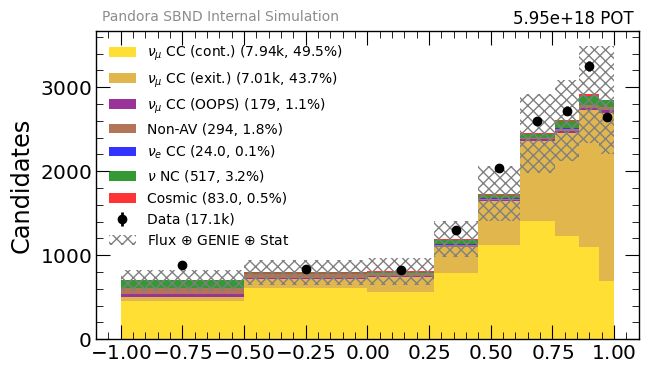

In [444]:
reco_costhetas = [s.data.mu.pfp.trk.costheta for s in slcs]
_costheta_data = _slc_data.data.mu.pfp.trk.costheta
yerr = systematics.systematics['total']['costheta_event_fracunc']*\
  (systematics.costheta_sel+systematics.costheta_sel_background)
tot_unc = systematics.systematics['total']['costheta_event_totalunc']

from sbnd.plotlibrary.makeplot import create_hist
yerr_label=r'Flux $\oplus$ GENIE $\oplus$ Stat'
fig,ax,n_perbin = create_hist(reco_costhetas,labels,bins=costheta_bins,yerr=yerr,yerr_label=yerr_label,data_series=_costheta_data,colors=colors,weights=slc_weights,label=PANDORA_QUALIFIER_INTERNAL_LABEL,return_counts=True,pot_label=POT_LABEL,savename=f'reco_costheta_fluxxsecsyst',plot_dir=f'{PLOT_DIR}/pandora/syst',close=False)

(0.0, 4.0)

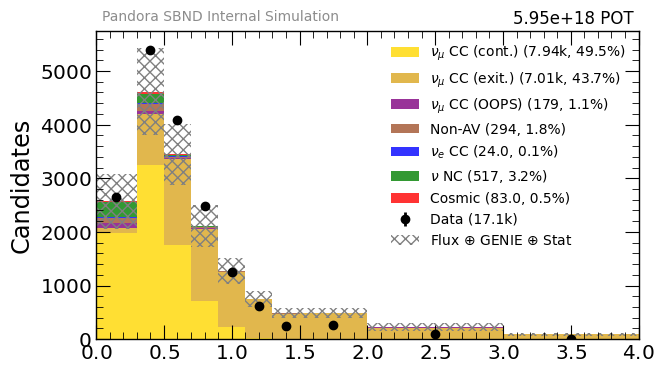

In [ ]:
reco_momentums = [s.data.mu.pfp.trk.P.p_muon for s in slcs]
_momentum_data = _slc_data.data.mu.pfp.trk.P.p_muon
yerr = systematics.systematics['total']['momentum_event_fracunc']*\
  (systematics.momentum_sel+systematics.momentum_sel_background)
tot_unc = systematics.systematics['total']['momentum_event_totalunc']

fig,ax,n_perbin = create_hist(reco_momentums,labels,bins=momentum_bins,yerr=yerr,yerr_label=yerr_label,data_series=_momentum_data,colors=colors,weights=slc_weights,label=PANDORA_QUALIFIER_INTERNAL_LABEL,return_counts=True,pot_label=POT_LABEL,savename=f'reco_momentum_fluxxsecsyst',plot_dir=f'{PLOT_DIR}/pandora/syst',close=False,bin_centers=momentum_centers)
ax.set_xlim(0,4)

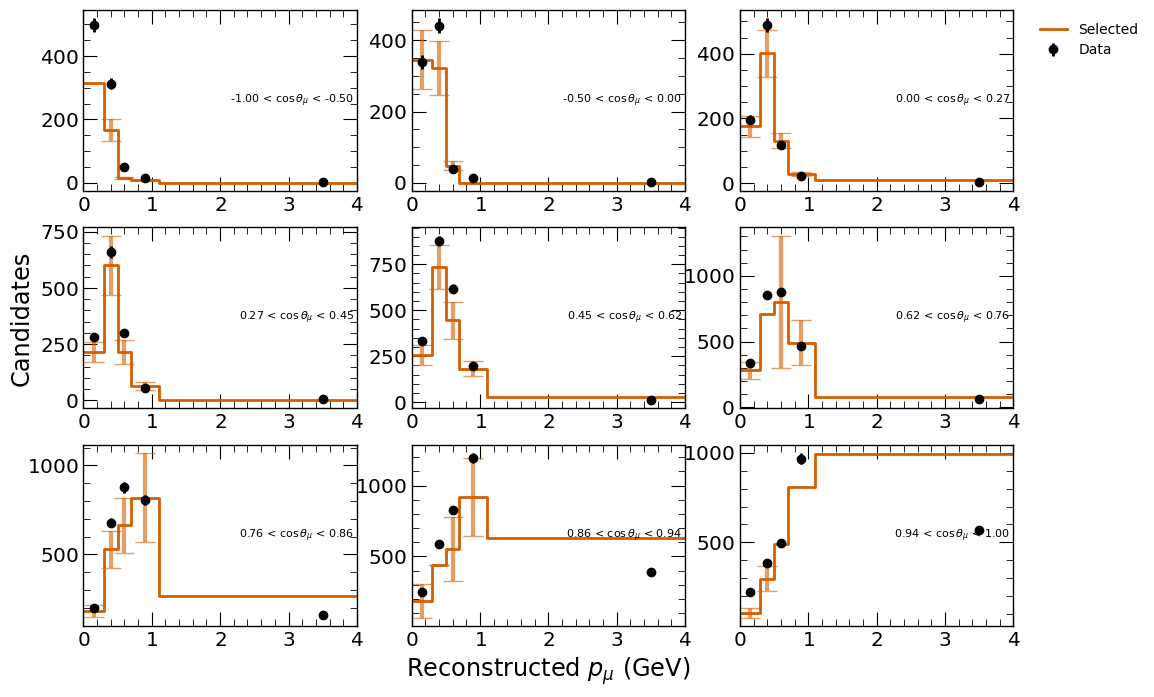

In [446]:
fig,axs = binning2d.plot_differential_hist(reco_sel_momentum,reco_sel_costheta_bin,diff_momentum_bins,genweights_sel,yerrs=systematics.systematics['total']['differential_event_fracunc'],label='Selected')
fig,axs = binning2d.plot_differential_scatter(_slc_data.data.mu.pfp.trk.P.p_muon,_slc_data.data.bin.costheta,diff_momentum_bins,fig=fig,axs=axs,legend=True,xlabel=r'Reconstructed $p_{\mu}$ (GeV)',add_labels=True,label='Data',bin_centers=diff_momentum_centers,color='black')

### 6.2 Uncertainties as function of kinematics

### 6.2.1 No det systematics

In [291]:
# No det systematics
# high_level_covs = [slc_flux_costheta_cov_noscale,slc_genie_costheta_cov_noscale,slc_stat_costheta_cov_noscale,slc_total_costheta_cov_noscale]
# yerrs = [np.sqrt(np.diag(cov))/n_perbin for cov in high_level_covs]
# labels = ['Flux','GENIE','Stat','Total']


In [ ]:
# from sbnd.plotlibrary import makeplot
# def plot_event_rate_errs(sys_col_dicts4func,base_key,bins,exclude_keys=[],include_keys=[],xlabel='',max_uncs=None):
#   """
#   Plot the event rate uncertainties for a given base key.

#   Parameters:
#   ----------
#     sys_col_dicts4func: dict
#       A dictionary of systematics.
#     base_key: str
#       The base key to plot.
#     bins: np.ndarray
#       The bins to plot.
#     exclude_keys: list
#       A list of keys to exclude from the plot.
#     include_keys: list
#       List of keys to include, if it's empty use all keys (except exclude keys duh)
#     xlabel: str
#       The x-axis label.
#     max_uncs: int
#       The maximum number of uncertainties to plot.
  
#   Returns:
#   --------
#     fig: matplotlib.figure.Figure
#       The figure.
#     ax: matplotlib.axes.Axes
#       The axes.
#   """
#   # Sort sys_col_dicts by total uncertainty (largest first)
#   sorted_items = sorted(
#     sys_col_dicts4func.items(), 
#     key=lambda x: x[1][f'{base_key}_totalunc'], 
#     reverse=True
#   )
#   if max_uncs == None:
#     max_uncs = len(sorted_items)
#   if len(include_keys) == 0:
#     include_keys = [item[0] for item in sorted_items]
#     if max_uncs == len(sorted_items):
#       max_uncs = len(include_keys)

#   unc_colors = plotters.get_colors('gist_rainbow', max_uncs+1)#, max_color=0.85)
#   fig, ax = plt.subplots()
#   cnt = 0
#   for i, (sys_name, sys_col_dict) in enumerate(sorted_items):
#     if cnt >= max_uncs:
#       break
#     if sys_name in exclude_keys or sys_name not in include_keys:
#       continue

#     cnt += 1
#     c = unc_colors[cnt]
#     label = f'{sys_col_dict["name"]} ({sys_col_dict[f"{base_key}_totalunc"]*100:.1f}%)'
#     makeplot.plot_hist_edges(
#         bins, 
#         sys_col_dict[f'{base_key}_fracunc'], 
#         None, 
#         ax=ax, 
#         label=label,
#         #color=c
#     )
#     #Label each bin with the uncertainty
#     #for j,bin_center in enumerate(costheta_centers):
#     #  ax.text(bin_center,yerr[j],f'{yerr[j]:.2f}',ha='center',va='bottom',color=c,fontsize=6)

#   ax.legend(ncol=int(np.ceil(max_uncs/24)), bbox_to_anchor=(1.05, 1.05))
#   ax.set_xlabel(xlabel)
#   if 'xsec' in base_key:
#     ax.set_ylabel(r'Cross Section Uncertainty')
#   else:
#     ax.set_ylabel(r'Event Rate Uncertainty')
#   if 'momentum' in base_key:
#     ax.set_xlim(0,4)
#   return fig,ax

In [336]:
list(systematics.systematics.keys())[0]

'expskin_Flux'

In [357]:
systematics.systematics['expskin_Flux']['costheta_event_fracunc']

array([0.01588247, 0.01567294, 0.0220493 , 0.01937315, 0.0263542 ,
       0.02904579, 0.03547816, 0.03806016, 0.05121243])

In [447]:
for var_name in tqdm(['costheta','momentum','differential'],unit=' goomba'):
  for unc_type in ['event','xsec']:
    if var_name == 'differential':
      bins = differential_edges
    elif var_name == 'costheta':
      bins = costheta_bins
    elif var_name == 'momentum':
      bins = momentum_bins
    fig,ax,im = systematics.plot_event_rate_errs(f'{var_name}_{unc_type}',bins,exclude_keys=summary_keys)
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'sel_{var_name}_{unc_type}_errs_full', fig=fig, folder_name=f'{PLOT_DIR}/pandora/syst')
    plt.close()

    fig,ax,im = systematics.plot_event_rate_errs(f'{var_name}_{unc_type}',bins,include_keys=summary_keys+['stat'])
    plotters.add_label(ax,PANDORA_QUALIFIER_INTERNAL_LABEL,where=(0.01,1.01+label_y_shift),fontsize=8,color='gray')
    plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='black',alpha=1.,fontsize=12)
    plotters.save_plot(f'sel_{var_name}_{unc_type}_errs_summary', fig=fig, folder_name=f'{PLOT_DIR}/pandora/syst')
    plt.close()
  #   break
  # break



100%|██████████| 3/3 [00:13<00:00,  4.59s/ goomba]


### 6.2.2 With det systematics

In [239]:
high_level_covs = [#slc_flux_costheta_cov_noscale,slc_genie_costheta_cov_noscale,slc_stat_costheta_cov_noscale,
pds_var_cov_noscale,sce_var_cov_noscale]
yerrs = [np.sqrt(np.diag(cov))/n_perbin for cov in high_level_covs]
labels = [#'Flux','GENIE','Stat',
'PDS','SCE']
unc_colors = plotters.get_colors('viridis',len(labels),max_color=0.8)
fig,ax = plt.subplots()
for i,(yerr,label) in enumerate(zip(yerrs,labels)):
  c = unc_colors[i]
  makeplot.plot_hist_edges(costheta_bins,yerr,None,ax=ax,color=c,label=label)
  #Label each bin with the uncertainty
  for j,bin_center in enumerate(costheta_centers):
    ax.text(bin_center,yerr[j],f'{yerr[j]:.2f}',ha='center',va='bottom',color=c,fontsize=6)
ax.legend()
ax.set_xlabel(r'Reconstructed $\cos\theta_{\mu}$')
ax.set_ylabel(r'Uncertainty')
plotters.save_plot('sel_costheta_yerrs_wdet_syst',fig=fig,folder_name=f'{PLOT_DIR}/pandora/syst')

NameError: name 'pds_var_cov_noscale' is not defined

## Testing

In [812]:
from analysis_village.unfolding.wienersvd import WienerSVD

print("=== Test 1: Perfect Case ===")
n_bins = 5
identity_response = np.eye(n_bins)
identity_response[1,0] = 0.1
test_signal = np.array([100.0, 100.0, 100.0, 100.0, 100.0])
test_measured = test_signal.copy()  # Same as signal
test_measured[1] = 1000.0
test_cov = np.diag(test_signal)*100  # Identity covariance

result1 = WienerSVD(identity_response, test_signal, test_measured, test_cov, 0, 0.0)
print(f"Unfolded result: {result1['unfold']}")
print(f"Should equal signal: {np.allclose(result1['unfold'], test_signal)}")
print(f"AddSmear should be identity: {np.allclose(result1['AddSmear'], np.eye(n_bins))}")
print("AddSmear matrix:")
print(result1['AddSmear'])
print(f"AddSmear diagonal: {np.diag(result1['AddSmear'])}")
print(f"AddSmear column sums: {np.sum(result1['AddSmear'], axis=0)}")

=== Test 1: Perfect Case ===
-Response: [[1.  0.  0.  0.  0. ]
 [0.1 1.  0.  0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1. ]]
-Signal: [100. 100. 100. 100. 100.]
-Measure: [ 100. 1000.  100.  100.  100.]
-Covariance: [[10000.     0.     0.     0.     0.]
 [    0. 10000.     0.     0.     0.]
 [    0.     0. 10000.     0.     0.]
 [    0.     0.     0. 10000.     0.]
 [    0.     0.     0.     0. 10000.]]
-C_type: 0
-Norm_type: 0.0
-U_cov: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-s_cov: [10000. 10000. 10000. 10000. 10000.]
-Q0: [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
-Q: [[0.01 0.   0.   0.   0.  ]
 [0.   0.01 0.   0.   0.  ]
 [0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]
 [0.   0.   0.   0.   0.01]]
-M_trans: [ 1. 10.  1.  1.  1.]
-R: [[0.01  0.    0.    0.    0.   ]
 [0.001 0.01  0.    0.    0.   ]
 [0.    0.    0.01  0.    0.   ]
 [0.    0.    0

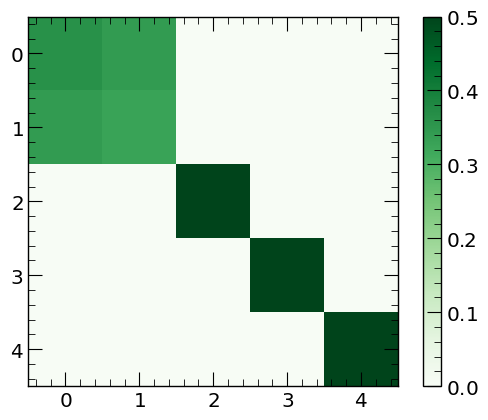

In [813]:
plt.imshow(result1['AddSmear'])
plt.colorbar()

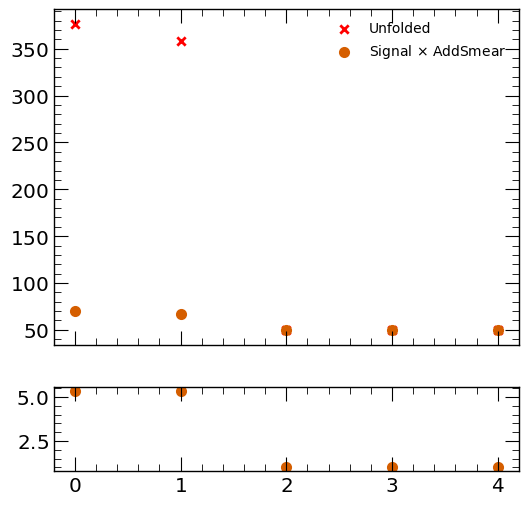

In [814]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(6,6),sharex=True,height_ratios=[4,1])
ax1.scatter(np.arange(n_bins),result1['unfold'],marker='x',color='red',label='Unfolded')
ax1.scatter(np.arange(n_bins),test_signal@result1['AddSmear'],label=r'Signal $\times$ AddSmear')
ax2.scatter(np.arange(n_bins),result1['unfold']/(test_signal@result1['AddSmear']))
ax1.legend()


In [808]:
_inter = inter.copy()

In [282]:
flux_keys = list(set([k[1] for k in _inter.data.keys() if 'Flux' in k[1]]))
with open('flux_keys.txt','w') as f:
  f.write(str(flux_keys))
flux_keys


['pionqexsec_Flux',
 'kplus_Flux',
 'pioninexsec_Flux',
 'nucleontotxsec_Flux',
 'nucleoninexsec_Flux',
 'horncurrent_Flux',
 'piplus_Flux',
 'piontotxsec_Flux',
 'kminus_Flux',
 'expskin_Flux',
 'nucleonqexsec_Flux',
 'Flux',
 'piminus_Flux',
 'kzero_Flux']

In [271]:
genie_keys = list(set([k[1] for k in slc.data.keys() if 'GENIE' in k[1]]))
genie_keys

['GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
 'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1eta',
 'GENIE',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvnCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC2pi',
 'GENIEReWeight_SBN_v1_multisigma_NormNCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NormCCCOH',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC1pi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpNC1pi',
 'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_RDecBR1gamma',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarpCC2pi',
 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
 'GENIEReWeight_SBN_v1_multisigma_NonRESBGvbarnNC2pi',
 'GENIEReWeight_SBN_v

In [83]:
_inter.add_stat_unc()

Generating event seeds: 100%|██████████| 309285/309285 [00:02<00:00, 110934.58it/s]


Successfully generated 309285 unique seeds


Generating universes: 100%|██████████| 100/100 [01:41<00:00,  1.02s/it]


In [86]:
_inter.data.truth.stat.univ_0.value_counts(normalize=True)

univ_0
1.0    0.367936
0.0    0.367386
2.0    0.184655
3.0    0.061238
4.0    0.015167
5.0    0.002971
6.0    0.000566
7.0    0.000061
8.0    0.000019
Name: proportion, dtype: float64

In [160]:
fname = f'{os.path.join(DATA_DIR,"small/mc_small_syst_postprocess_cut.df")}'
#df = pd.read_hdf(fname,key='evt_0')

In [38]:
list(df.keys())

[('id', '', '', '', '', ''),
 ('is_cathode_crosser_x', '', '', '', '', ''),
 ('is_contained_x', '', '', '', '', ''),
 ('is_fiducial_x', '', '', '', '', ''),
 ('is_flash_matched', '', '', '', '', ''),
 ('is_truth', '', '', '', '', ''),
 ('num_particles_x', '', '', '', '', ''),
 ('num_primary_particles_x', '', '', '', '', ''),
 ('vertex', 'x', '', '', '', ''),
 ('vertex', 'y', '', '', '', ''),
 ('vertex', 'z', '', '', '', ''),
 ('flash_hypo_pe', '', '', '', '', ''),
 ('flash_total_pe', '', '', '', '', ''),
 ('match_overlaps', '', '', '', '', ''),
 ('current_type', '', '', '', '', ''),
 ('energy_init', '', '', '', '', ''),
 ('energy_transfer', '', '', '', '', ''),
 ('num_particles_y', '', '', '', '', ''),
 ('num_primary_particles_y', '', '', '', '', ''),
 ('inelasticity', '', '', '', '', ''),
 ('interaction_mode', '', '', '', '', ''),
 ('interaction_type', '', '', '', '', ''),
 ('is_cathode_crosser_y', '', '', '', '', ''),
 ('is_contained_y', '', '', '', '', ''),
 ('is_fiducial_y', '', ''

In [161]:
with h5py.File(fname, 'r') as f:
    keys = list(f.keys())  # Convert the KeysViewWithLock object to a list for easier viewing
    print(keys)

['mcnu', 'pandora', 'pandora_signal', 'spine', 'spine_signal']
